In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [2]:
# Load data
print("Loading data...")
train_df = pd.read_csv('trademaster25/train_v2.csv')
test_df = pd.read_csv('trademaster25/test_v2.csv')

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")

# Feature and target columns
target_cols = ['target_short', 'target_medium', 'target_long']
TARGET_WEIGHTS = {'short': 0.5, 'medium': 0.3, 'long': 0.2}

# 动态定义 feature_cols
# 1. date_id: 通常用于交叉验证分组 (CV Grouping)，不作为直接特征，防止过拟合时间。
# 2. minute_id: 如果是日内时间，可以作为特征；如果是全局时间戳，应排除。这里默认排除，防止作为 ID 泄漏。
ignore_cols = ['id', 'date_id', 'minute_id'] + target_cols
feature_cols = [f'feature_{i}' for i in range(1, 31)]

print(f"Features: {len(feature_cols)}")
print(f"Targets: {target_cols}")
print(f"Weights: {TARGET_WEIGHTS}")

if 'date_id' in train_df.columns:
    print("✅ Found 'date_id': Will be used for PurgedGroupTimeSeriesSplit.")
if 'minute_id' in train_df.columns:
    print("ℹ️ Found 'minute_id': Excluded from raw features.")

Loading data...
Training set: (139392, 37)
Test set: (34348, 34)
Features: 30
Targets: ['target_short', 'target_medium', 'target_long']
Weights: {'short': 0.5, 'medium': 0.3, 'long': 0.2}
✅ Found 'date_id': Will be used for PurgedGroupTimeSeriesSplit.
ℹ️ Found 'minute_id': Excluded from raw features.


In [3]:
train_df.describe()

,id,date_id,minute_id,stock_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,target_short,target_medium,target_long
count,139392.000000,139392.000000,139392.000000,139392.0,139392.000000,1.393910e+05,139382.000000,139379.000000,139362.000000,139392.000000,...,139373.000000,139358.000000,139363.000000,139392.000000,139391.000000,139362.000000,139362.000000,139392.000000,139392.000000,139392.000000
mean,69695.500000,289.900138,119.466942,0.0,0.100651,-inf,-0.002015,0.067555,0.137022,-0.004771,...,0.010554,-52.780710,0.004630,0.399447,-0.000003,0.000934,-0.000098,-0.000033,-0.000192,-0.000766
std,40239.148699,167.663109,69.270219,0.0,0.300868,NaN,0.226708,0.042766,0.964826,1.020697,...,0.009089,31.683331,1.090614,0.230623,0.001940,0.000715,0.010186,0.005871,0.014408,0.028882
min,0.000000,0.000000,0.000000,0.0,0.000000,-inf,-5.270000,0.000000,-5.477226,-1.904991,...,0.000000,-100.000000,-3.648028,0.000000,-0.093234,0.000000,-0.090227,-0.091812,-0.086804,-0.131662
25%,34847.750000,145.000000,59.000000,0.0,0.000000,-3.201773e-04,-0.090000,0.039286,-0.264227,-0.803271,...,0.005339,-81.395349,-0.701752,0.199723,-0.000807,0.000552,-0.004991,-0.002650,-0.007663,-0.018639
50%,69695.500000,290.000000,119.000000,0.0,0.000000,0.000000e+00,-0.010000,0.057143,0.160343,0.031092,...,0.008077,-54.726912,-0.282123,0.399447,0.000000,0.000764,-0.000569,-0.000275,-0.000962,-0.003101
75%,104543.250000,435.000000,179.000000,0.0,0.000000,3.548881e-04,0.080000,0.082143,0.568293,0.811304,...,0.012601,-25.000000,0.418252,0.599170,0.000712,0.001073,0.004059,0.002328,0.006019,0.015318
max,139391.000000,580.000000,239.000000,0.0,1.000000,4.886260e+00,4.370000,0.774286,5.477226,1.904696,...,0.157762,-0.000000,5.293741,0.798894,0.060000,0.016995,0.101807,0.095770,0.095640,0.164725


处理缺失值和outliers

In [41]:
# Fill NaN with median and clip extreme values
for col in feature_cols:
    median_val = train_df[col].median()
    train_df[col].fillna(median_val, inplace=True)
    test_df[col].fillna(median_val, inplace=True)

    # Clip extreme values at 1% and 99% quantiles
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(lower, upper)
    test_df[col] = test_df[col].clip(lower, upper)

### Feature Engineering for XGBoost
Prepare stationary and interaction features (diffs, time-derived signals, log transforms, ratios) before running tree-based models.

In [ ]:
# NOTE: Run this cell before training XGBoost-based models.
from typing import List

print("Applying feature engineering for XGBoost (stationarity, time features, interactions)...")

# Helper configuration
feature_6_min = min(train_df['feature_6'].min(), test_df['feature_6'].min()) if 'feature_6' in train_df.columns else 0
feature_6_max = max(train_df['feature_6'].max(), test_df['feature_6'].max()) if 'feature_6' in train_df.columns else 0

# Columns to use when computing group-wise differences (if available)
group_candidates: List[str] = [
    col for col in ['date_id', 'time_id', 'stock_id'] if col in train_df.columns
]

# Ensure feature column list exists
if 'feature_cols' not in globals():
    feature_cols = [c for c in train_df.columns if c.startswith('feature_')]

# 1. Stationary transformation for feature_11 -> f11_diff (drop original)
for df_name, df in [('train', train_df), ('test', test_df)]:
    if 'feature_11' in df.columns:
        if group_candidates:
            df['f11_diff'] = df.groupby(group_candidates)['feature_11'].diff()
        else:
            df['f11_diff'] = df['feature_11'].diff()
        df['f11_diff'].fillna(0.0, inplace=True)
        df.drop(columns='feature_11', inplace=True)
    elif 'f11_diff' not in df.columns:
        df['f11_diff'] = 0.0

# 2. Drop low-value raw feature_27
for df in [train_df, test_df]:
    if 'feature_27' in df.columns:
        df.drop(columns='feature_27', inplace=True)

# 3. Intraday time derivatives from feature_6
if 'feature_6' in train_df.columns:
    for df_name, df in [('train', train_df), ('test', test_df)]:
        df['dist_to_open'] = df['feature_6'] - feature_6_min
        df['dist_to_close'] = feature_6_max - df['feature_6']
        df['is_midday'] = ((df['feature_6'] > 85) & (df['feature_6'] < 190)).astype(int)
        df['volatility_time_norm'] = df['feature_4'] / (df['feature_6'] - feature_6_min + 10)
        df['late_session_flow'] = df['feature_4'] * (df['feature_6'] > 200).astype(int)

# 4. Log transforms to spread long-tailed signals
for col in ['feature_4', 'feature_13', 'feature_14']:
    if col in train_df.columns:
        train_df[f'{col}_log1p'] = np.log1p(np.clip(train_df[col], a_min=0, a_max=None))
        test_df[f'{col}_log1p'] = np.log1p(np.clip(test_df[col], a_min=0, a_max=None))

# 5. Ratio-style features for risk/liquidity interpretation
if 'feature_4' in train_df.columns and 'f11_diff' in train_df.columns:
    denom = lambda x: x.replace(0, np.nan)
    train_df['f11_diff_div_f4'] = train_df['f11_diff'] / denom(train_df['feature_4'])
    test_df['f11_diff_div_f4'] = test_df['f11_diff'] / denom(test_df['feature_4'])
    train_df['f11_diff_div_f4'].replace([np.inf, -np.inf], 0.0, inplace=True)
    test_df['f11_diff_div_f4'].replace([np.inf, -np.inf], 0.0, inplace=True)
    train_df['f11_diff_div_f4'].fillna(0.0, inplace=True)
    test_df['f11_diff_div_f4'].fillna(0.0, inplace=True)

if 'feature_13' in train_df.columns and 'feature_4' in train_df.columns:
    denom = lambda x: x.replace(0, np.nan)
    train_df['feature_13_div_f4'] = train_df['feature_13'] / denom(train_df['feature_4'])
    test_df['feature_13_div_f4'] = test_df['feature_13'] / denom(test_df['feature_4'])
    for df in [train_df, test_df]:
        df['feature_13_div_f4'].replace([np.inf, -np.inf], 0.0, inplace=True)
        df['feature_13_div_f4'].fillna(0.0, inplace=True)

# 6. Categorical handling for low-cardinality features
for cat_col in ['feature_1', 'feature_8', 'feature_12']:
    if cat_col in train_df.columns:
        train_df[cat_col] = train_df[cat_col].astype('category')
        test_df[cat_col] = test_df[cat_col].astype('category')

# Count encoding for feature_8 (using train distribution)
if 'feature_8' in train_df.columns:
    feature_8_counts = train_df['feature_8'].value_counts()
    for df in [train_df, test_df]:
        mapped_counts = df['feature_8'].map(feature_8_counts).astype('float64')
        df.drop(columns=['feature_8_count'], errors='ignore', inplace=True)
        df['feature_8_count'] = mapped_counts.fillna(0.0)

# 7. Update feature column registry
new_features = [
    'f11_diff', 'dist_to_open', 'dist_to_close', 'is_midday',
    'volatility_time_norm', 'late_session_flow',
    'feature_4_log1p', 'feature_13_log1p', 'feature_14_log1p',
    'f11_diff_div_f4', 'feature_13_div_f4', 'feature_8_count'
]

dropped_features = ['feature_11', 'feature_27']
feature_cols = [col for col in feature_cols if col not in dropped_features]
for extra in new_features:
    if extra not in feature_cols:
        feature_cols.append(extra)

print(f"Updated feature set size: {len(feature_cols)}")

## 0. EDA
特征可视化

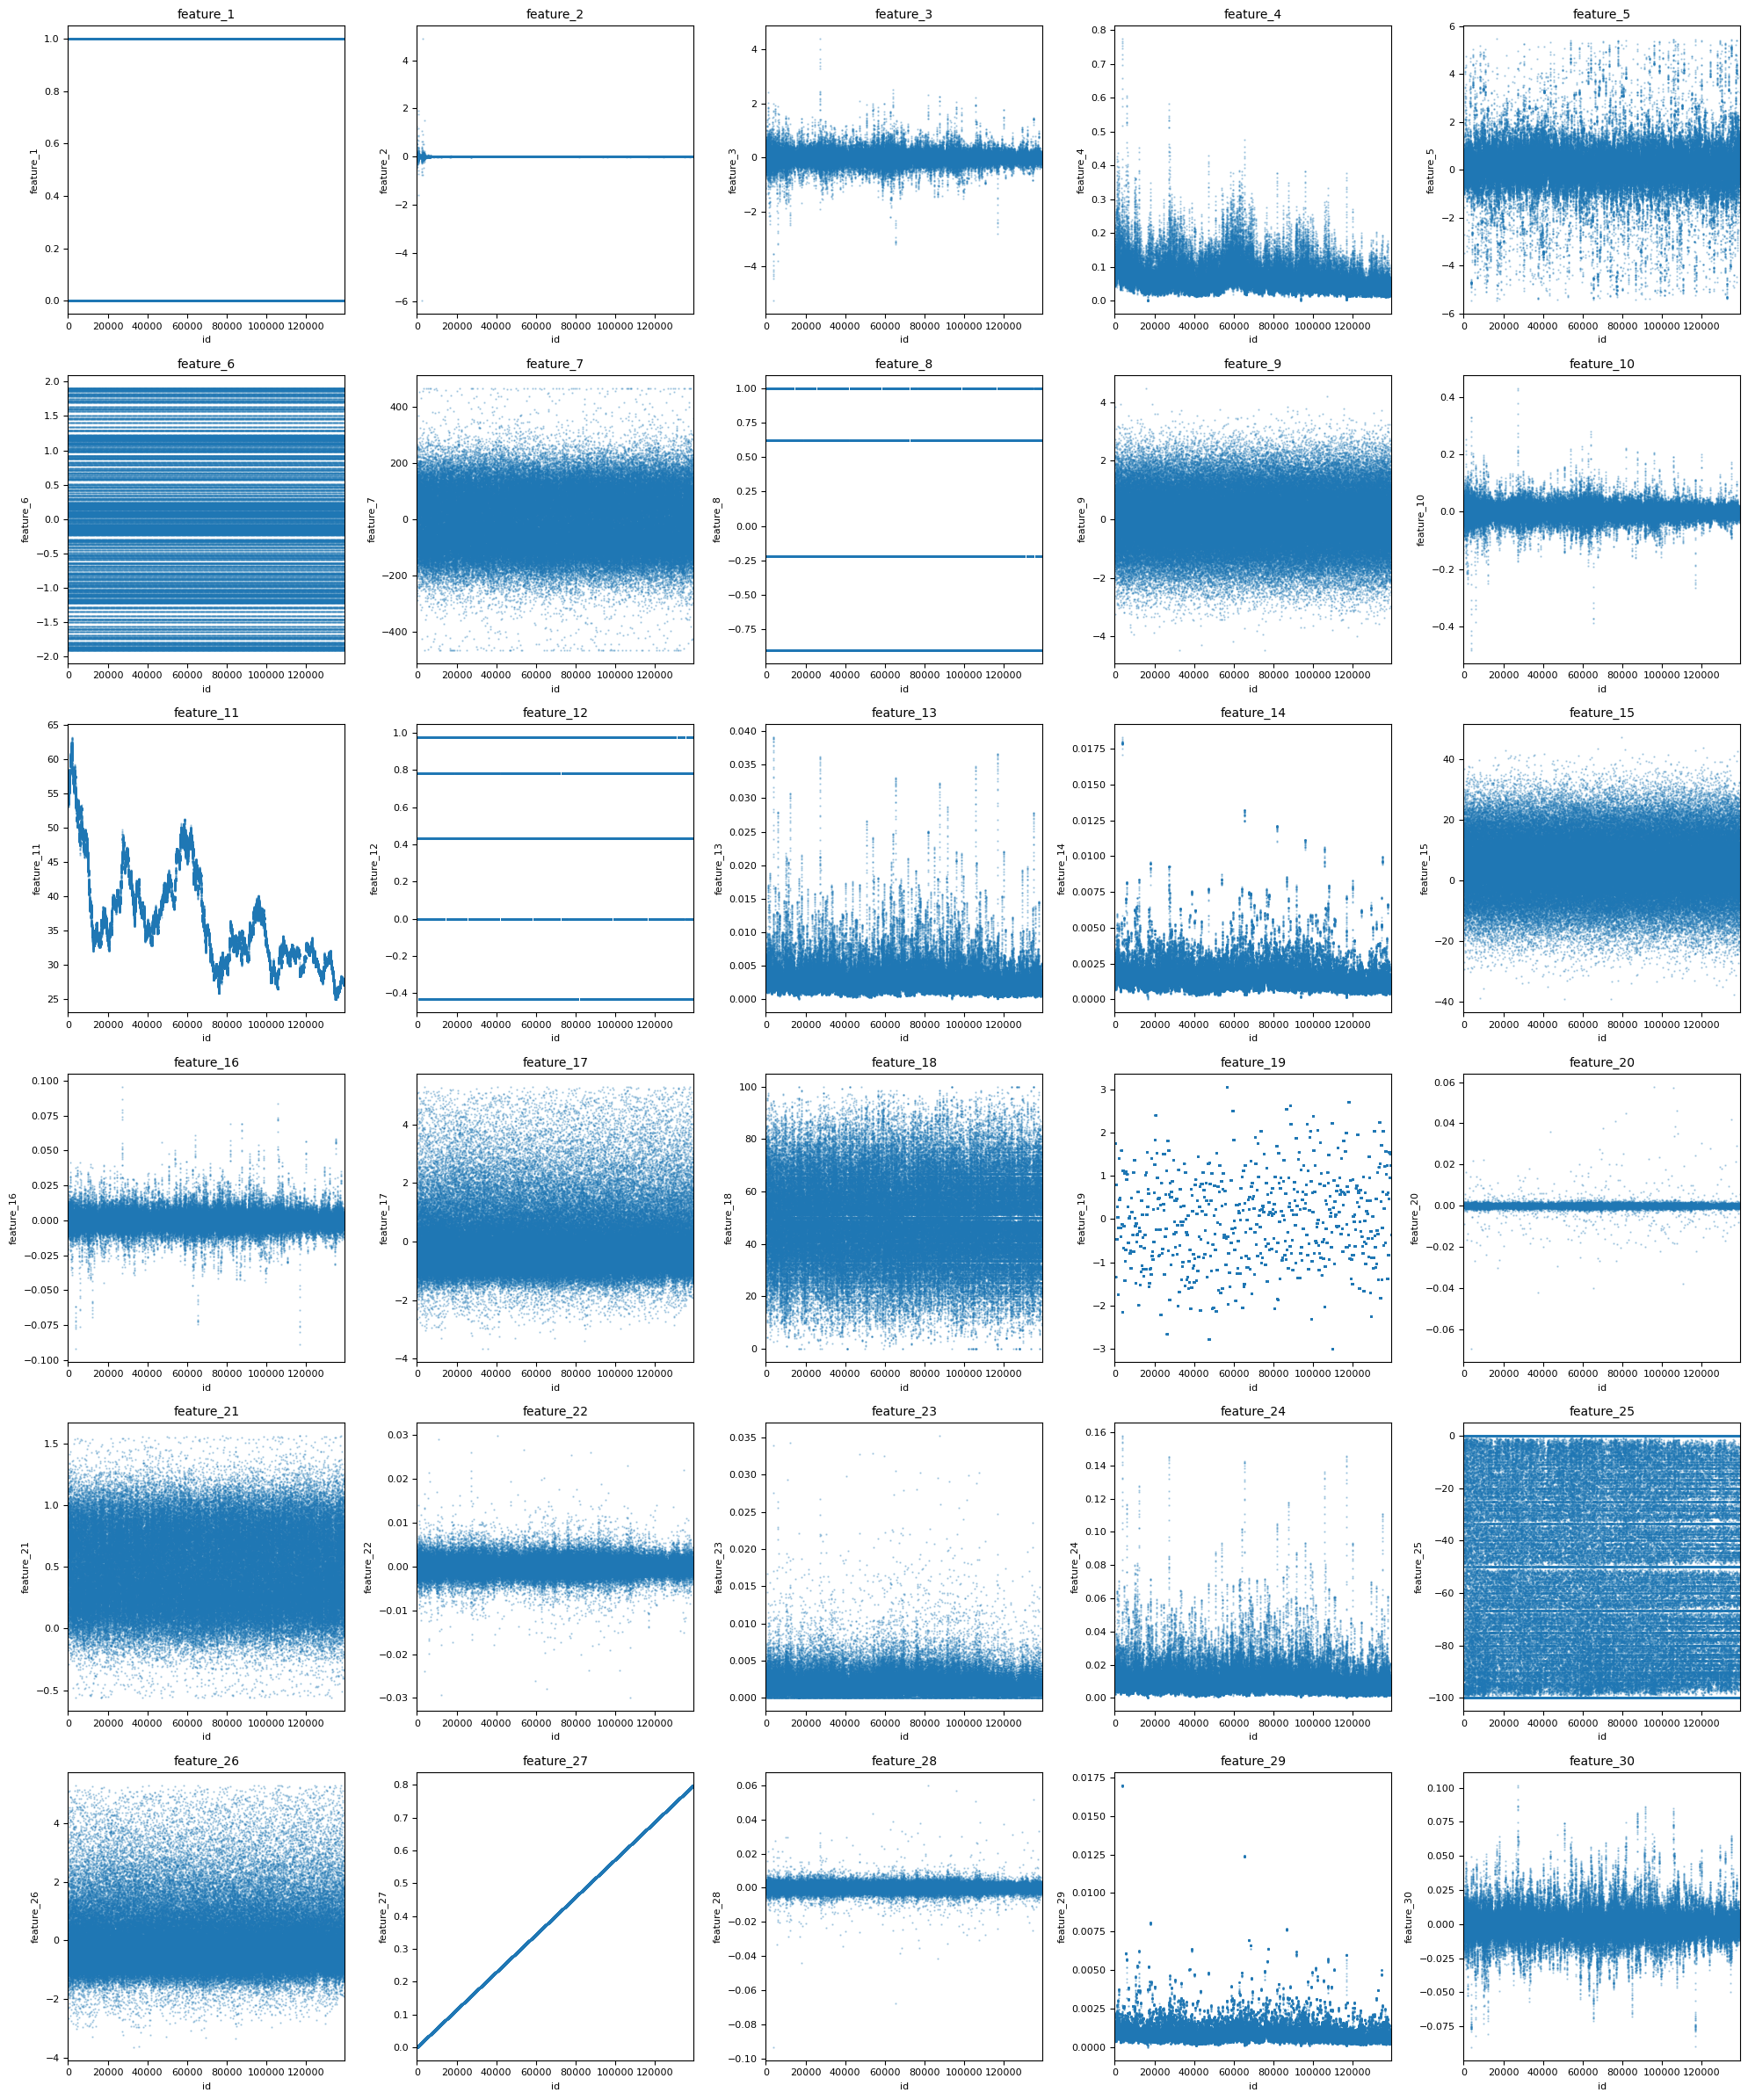

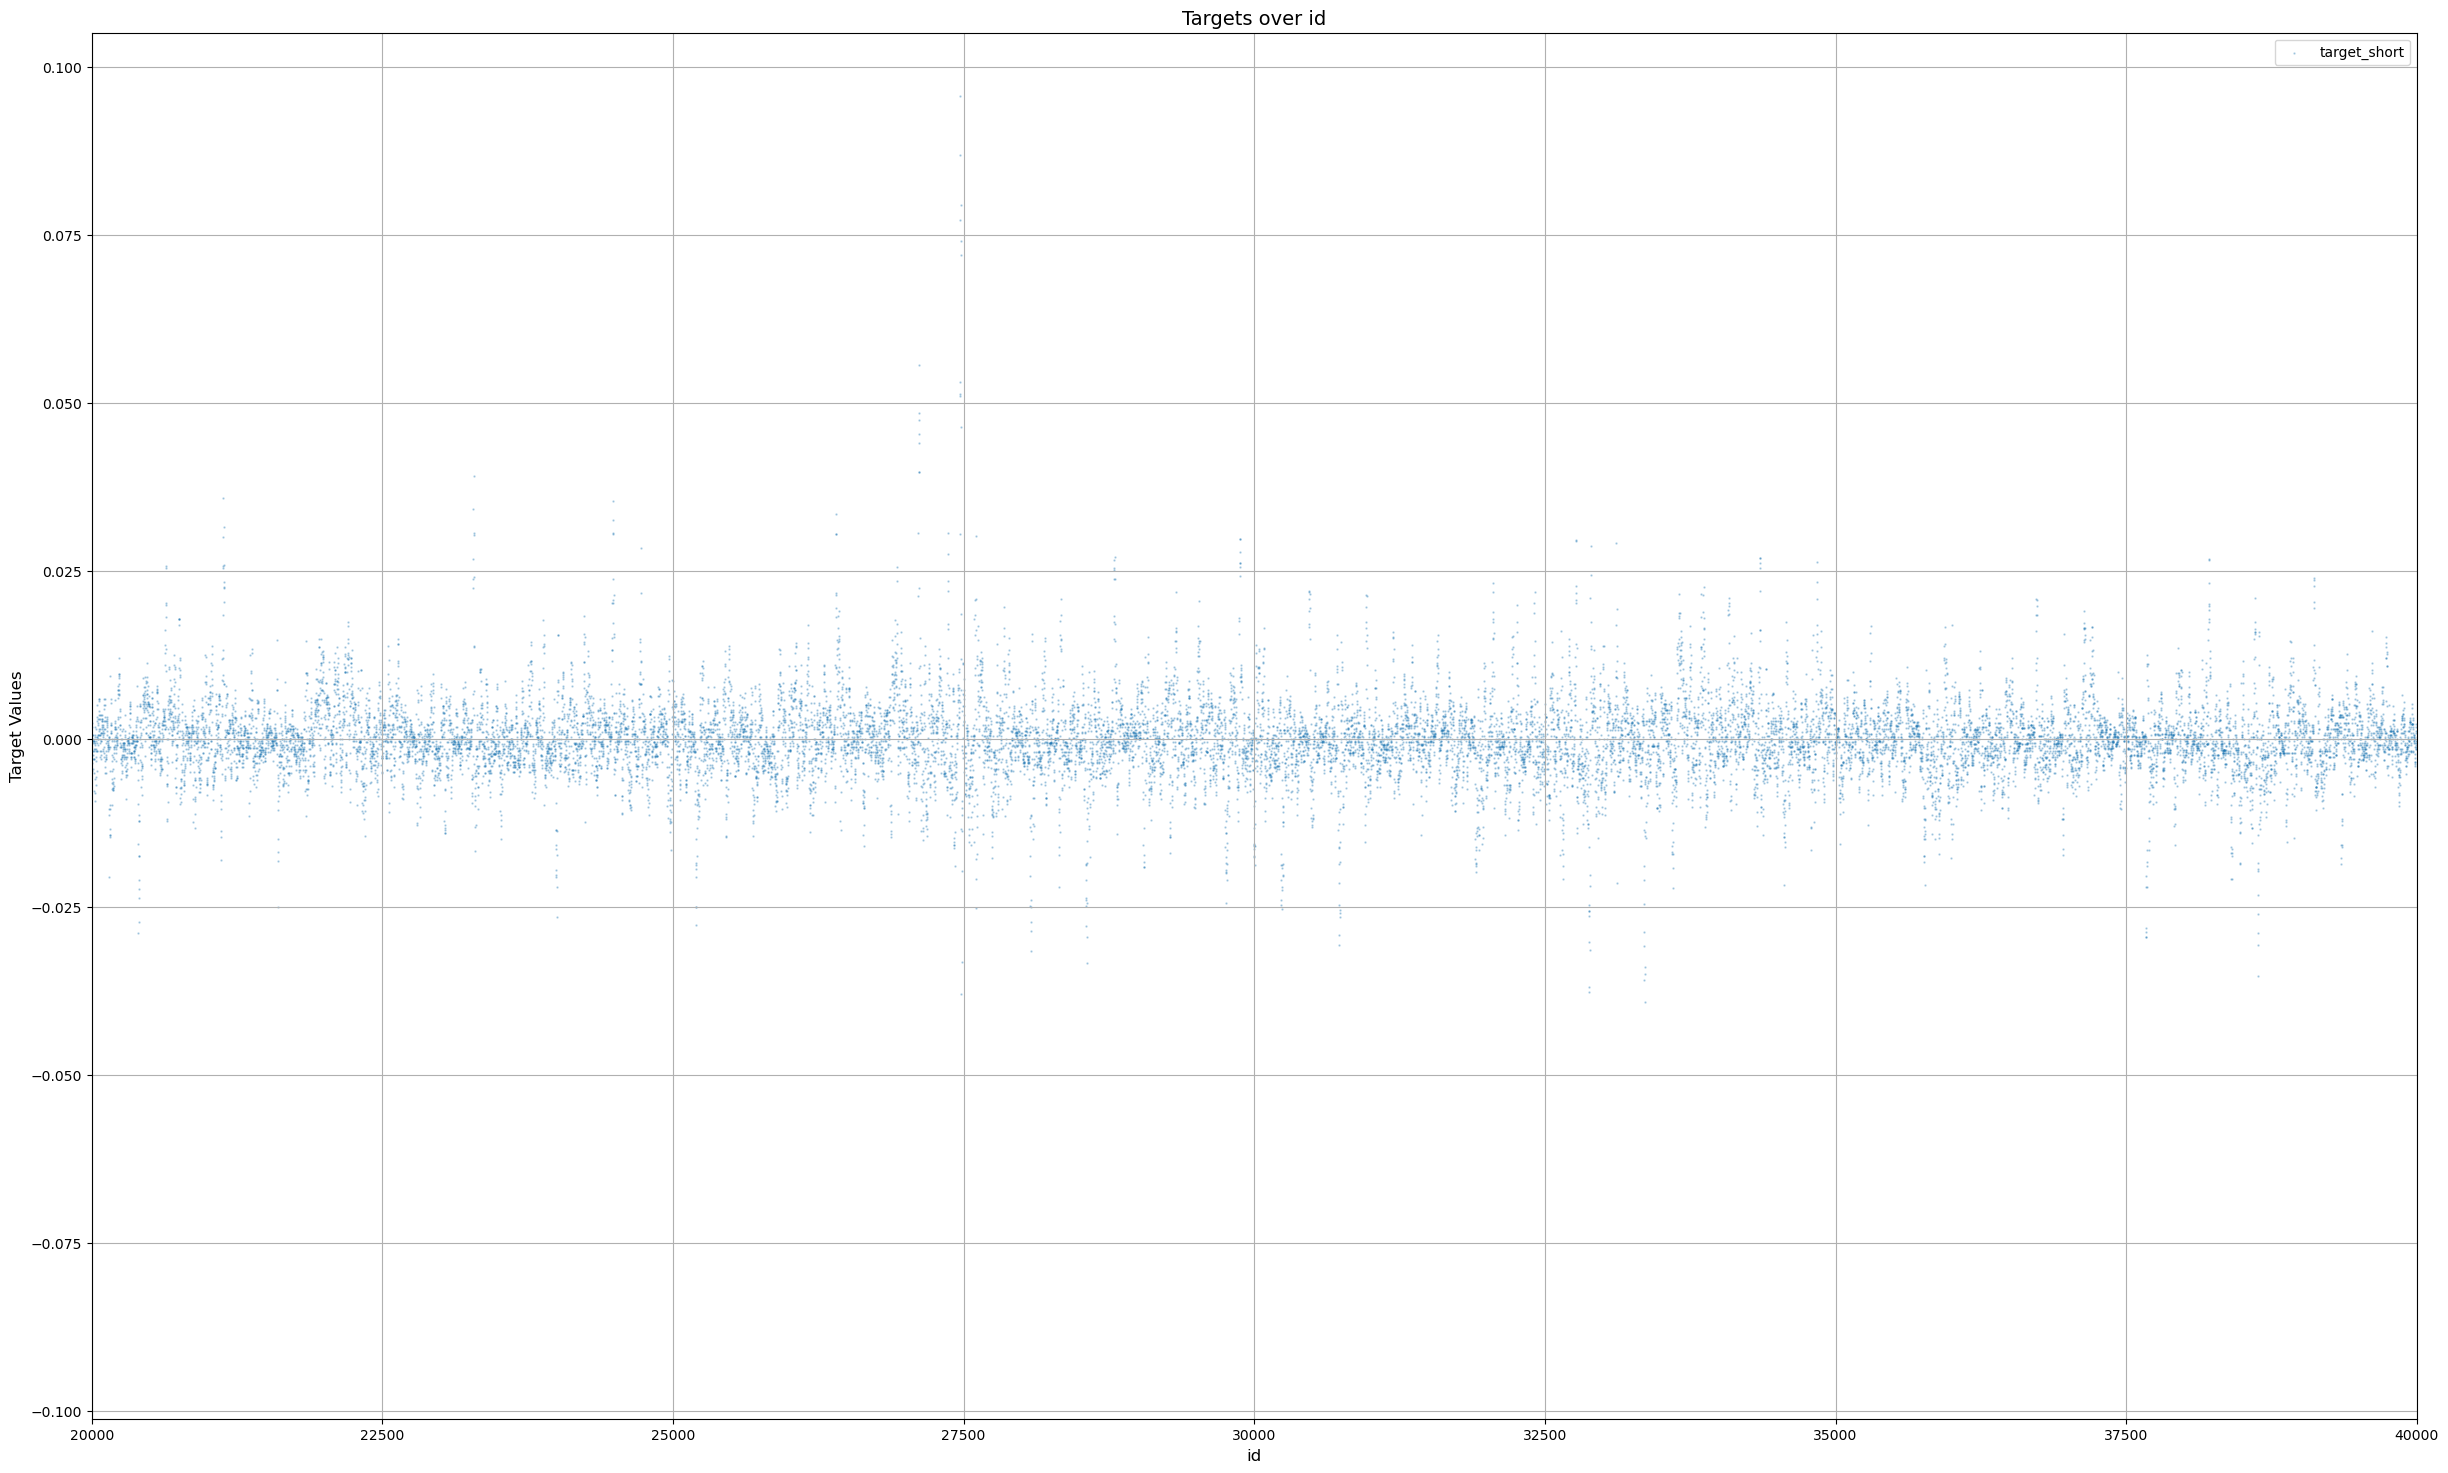

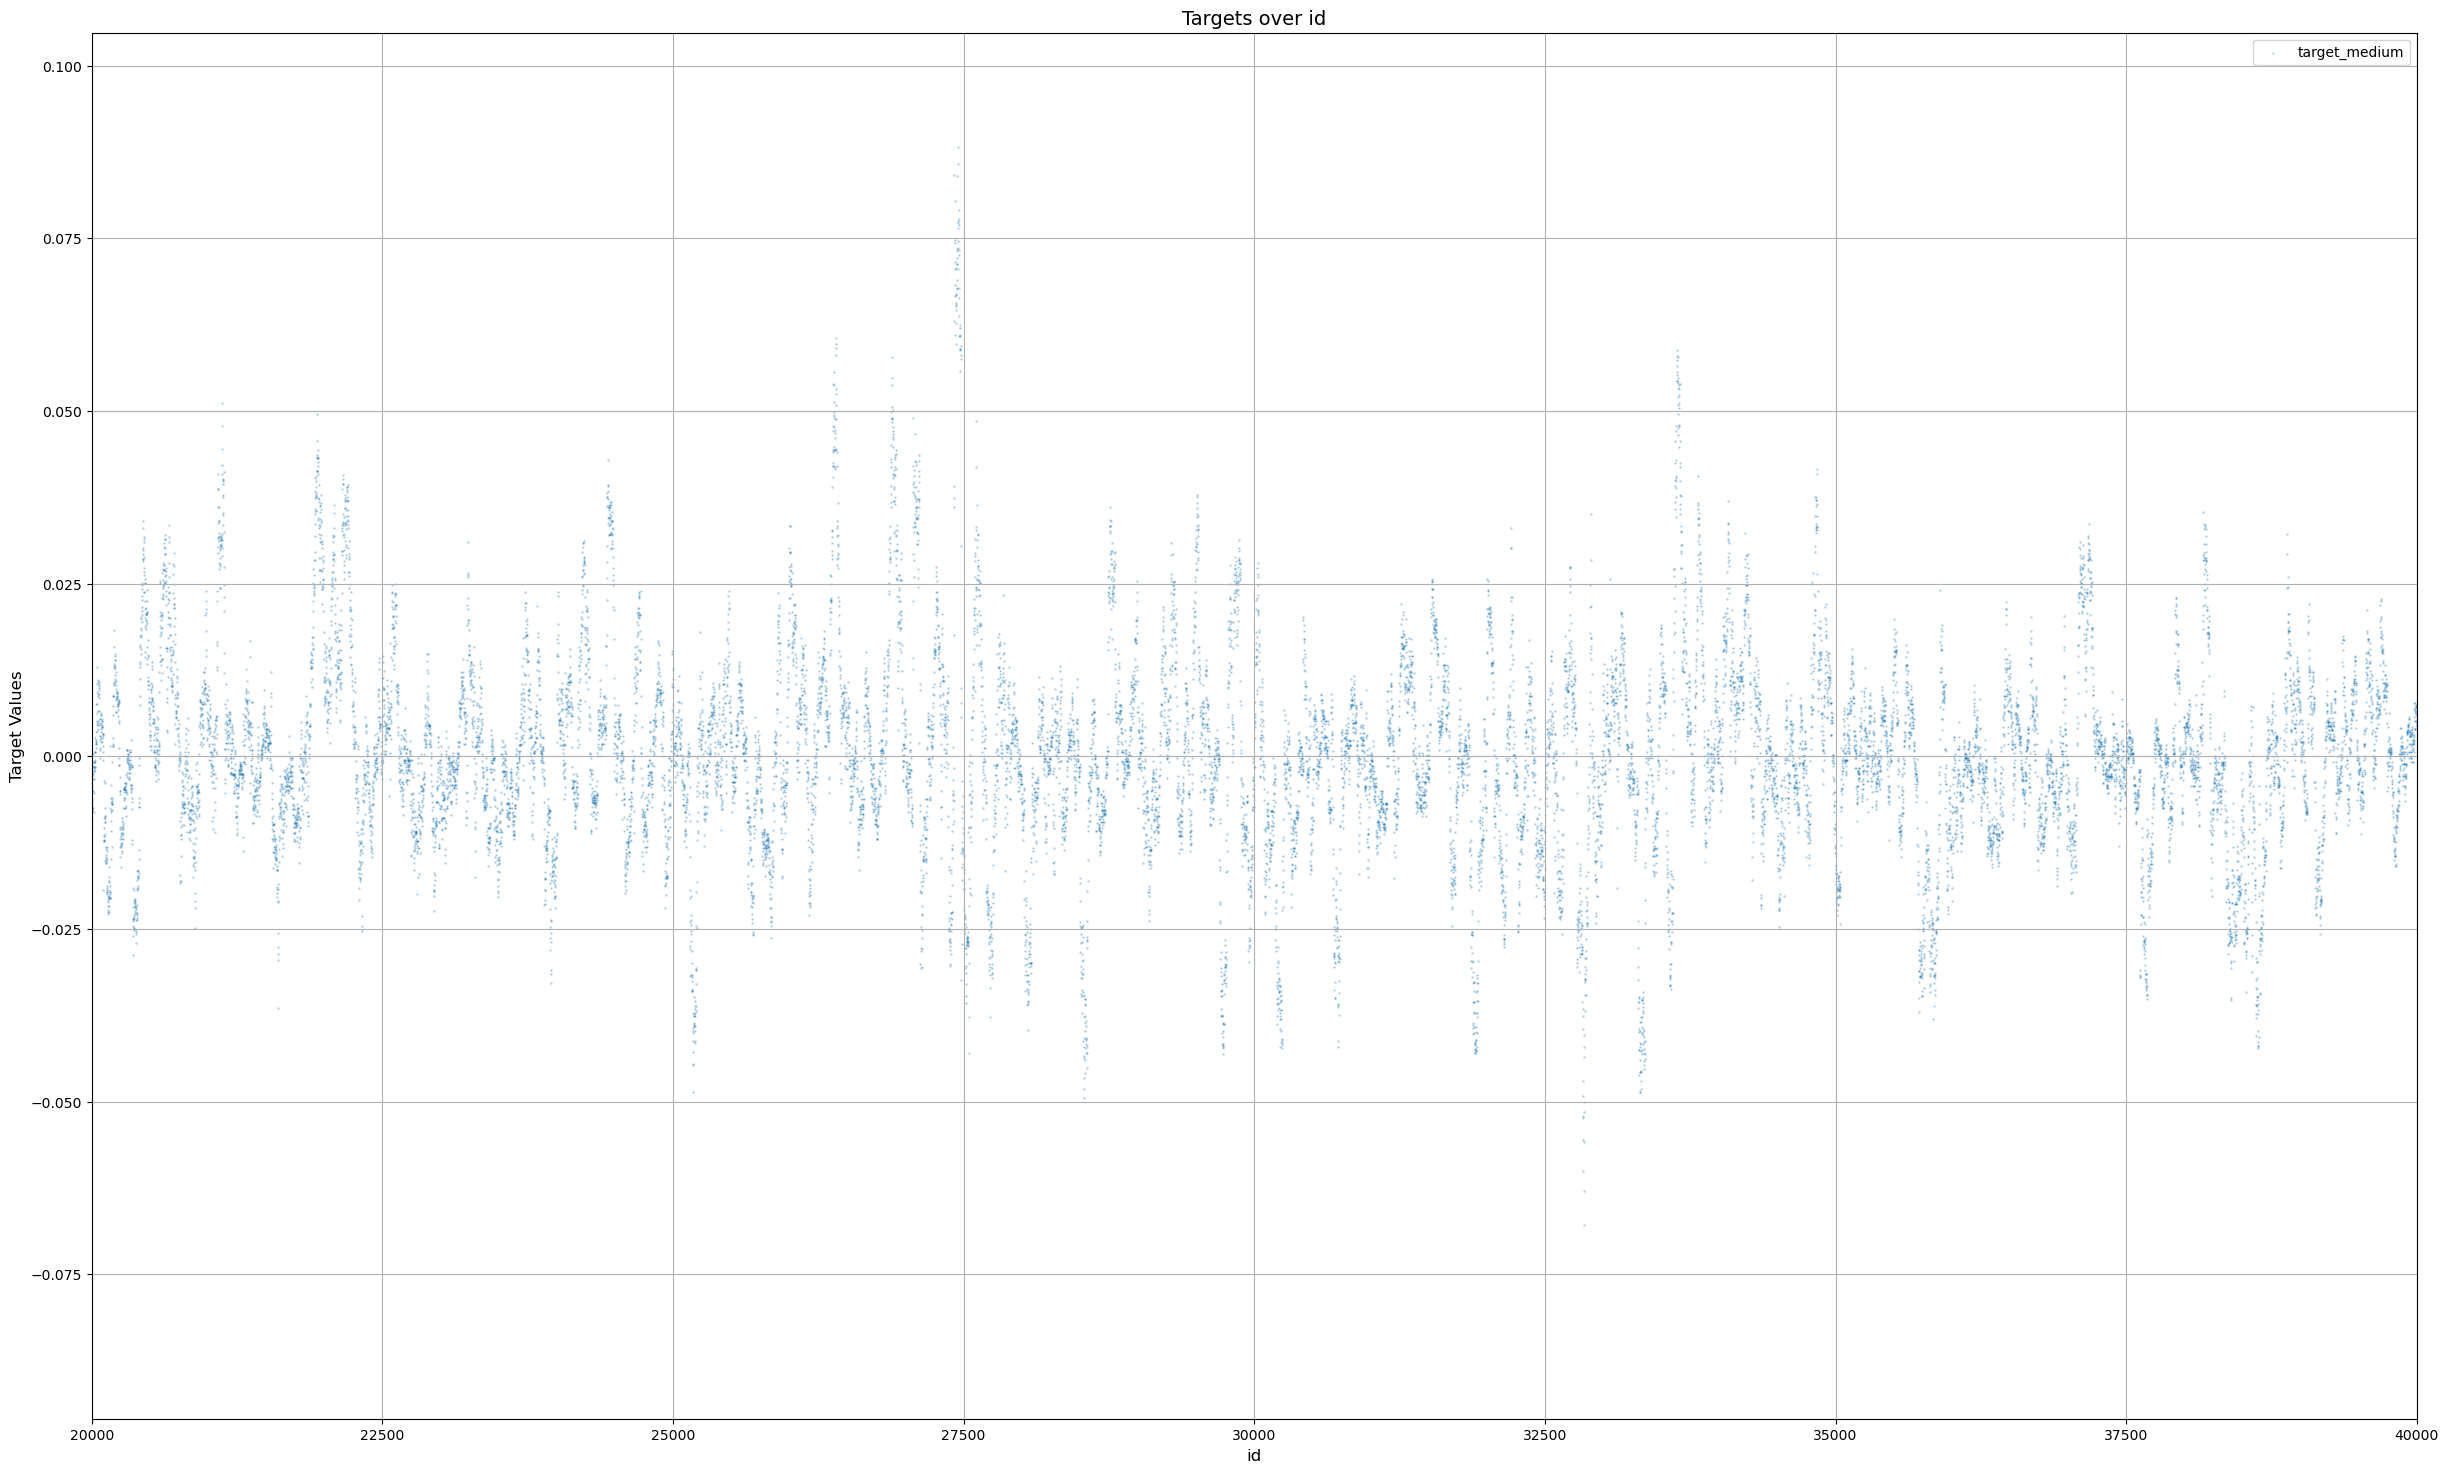

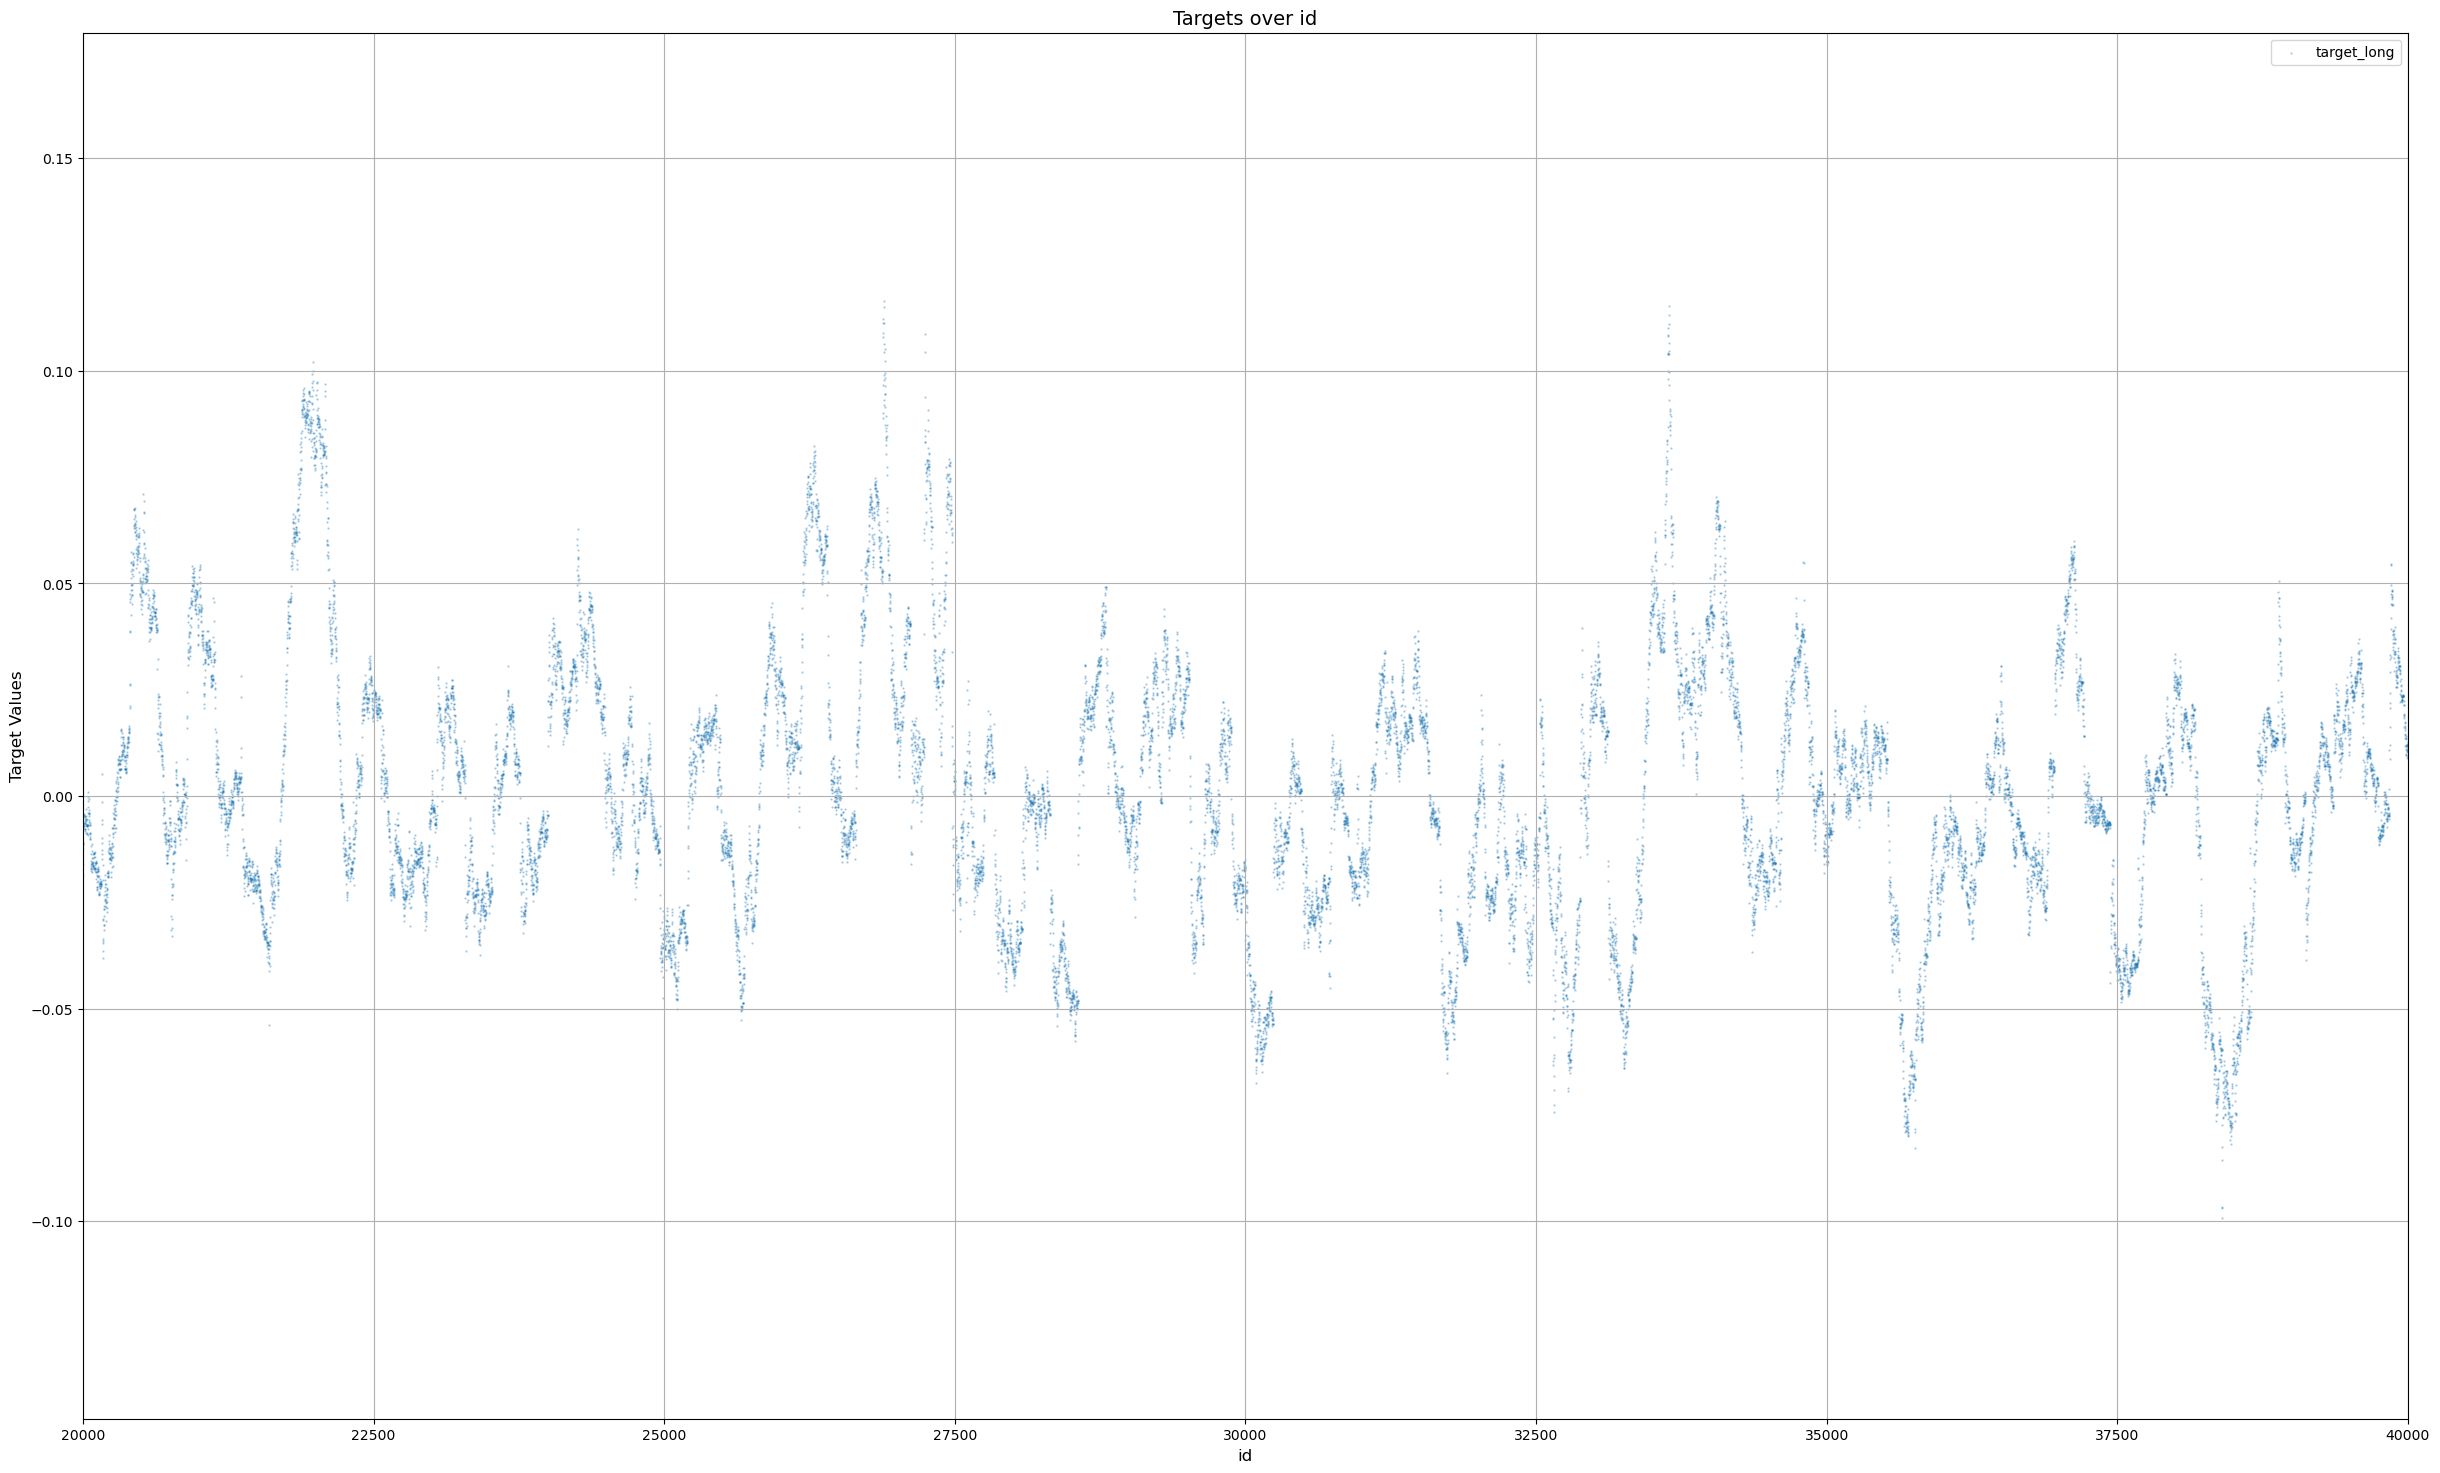

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature and target columns
features = [c for c in train_df.columns if c.startswith('feature')]
targets = [c for c in train_df.columns if c.startswith('target')]

# Get minute_id range
min_minute = train_df['minute_id'].min()
max_minute = train_df['minute_id'].max()

# Plot all features in one figure
n_features = len(features)
n_cols = 6
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, f in enumerate(features):
    axes[i].scatter(train_df['id'], train_df[f], alpha=0.3, s=0.5)
    axes[i].set_title(f, fontsize=8)
    axes[i].set_xlabel('id', fontsize=6)
    axes[i].set_ylabel(f, fontsize=6)
    axes[i].set_xlim(0, train_df['id'].max())
    axes[i].tick_params(labelsize=6)

# Hide unused subplots
for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


#上面的改成一个一个图显示
for t in targets:
    plt.figure(figsize=(10, 6))
    plt.scatter(train_df['id'], train_df[t], alpha=0.3, s=0.5, label=t)
    plt.title('Targets over id', fontsize=14)
    plt.xlabel('id', fontsize=12)
    plt.ylabel('Target Values', fontsize=12)
    plt.xlim(20000, 40000)
    plt.legend()
    plt.grid(True)
    plt.show()

### Feature Correlation Heatmap
This section visualizes the correlation between numerical features in `trademaster25/train.csv`, excluding target columns.

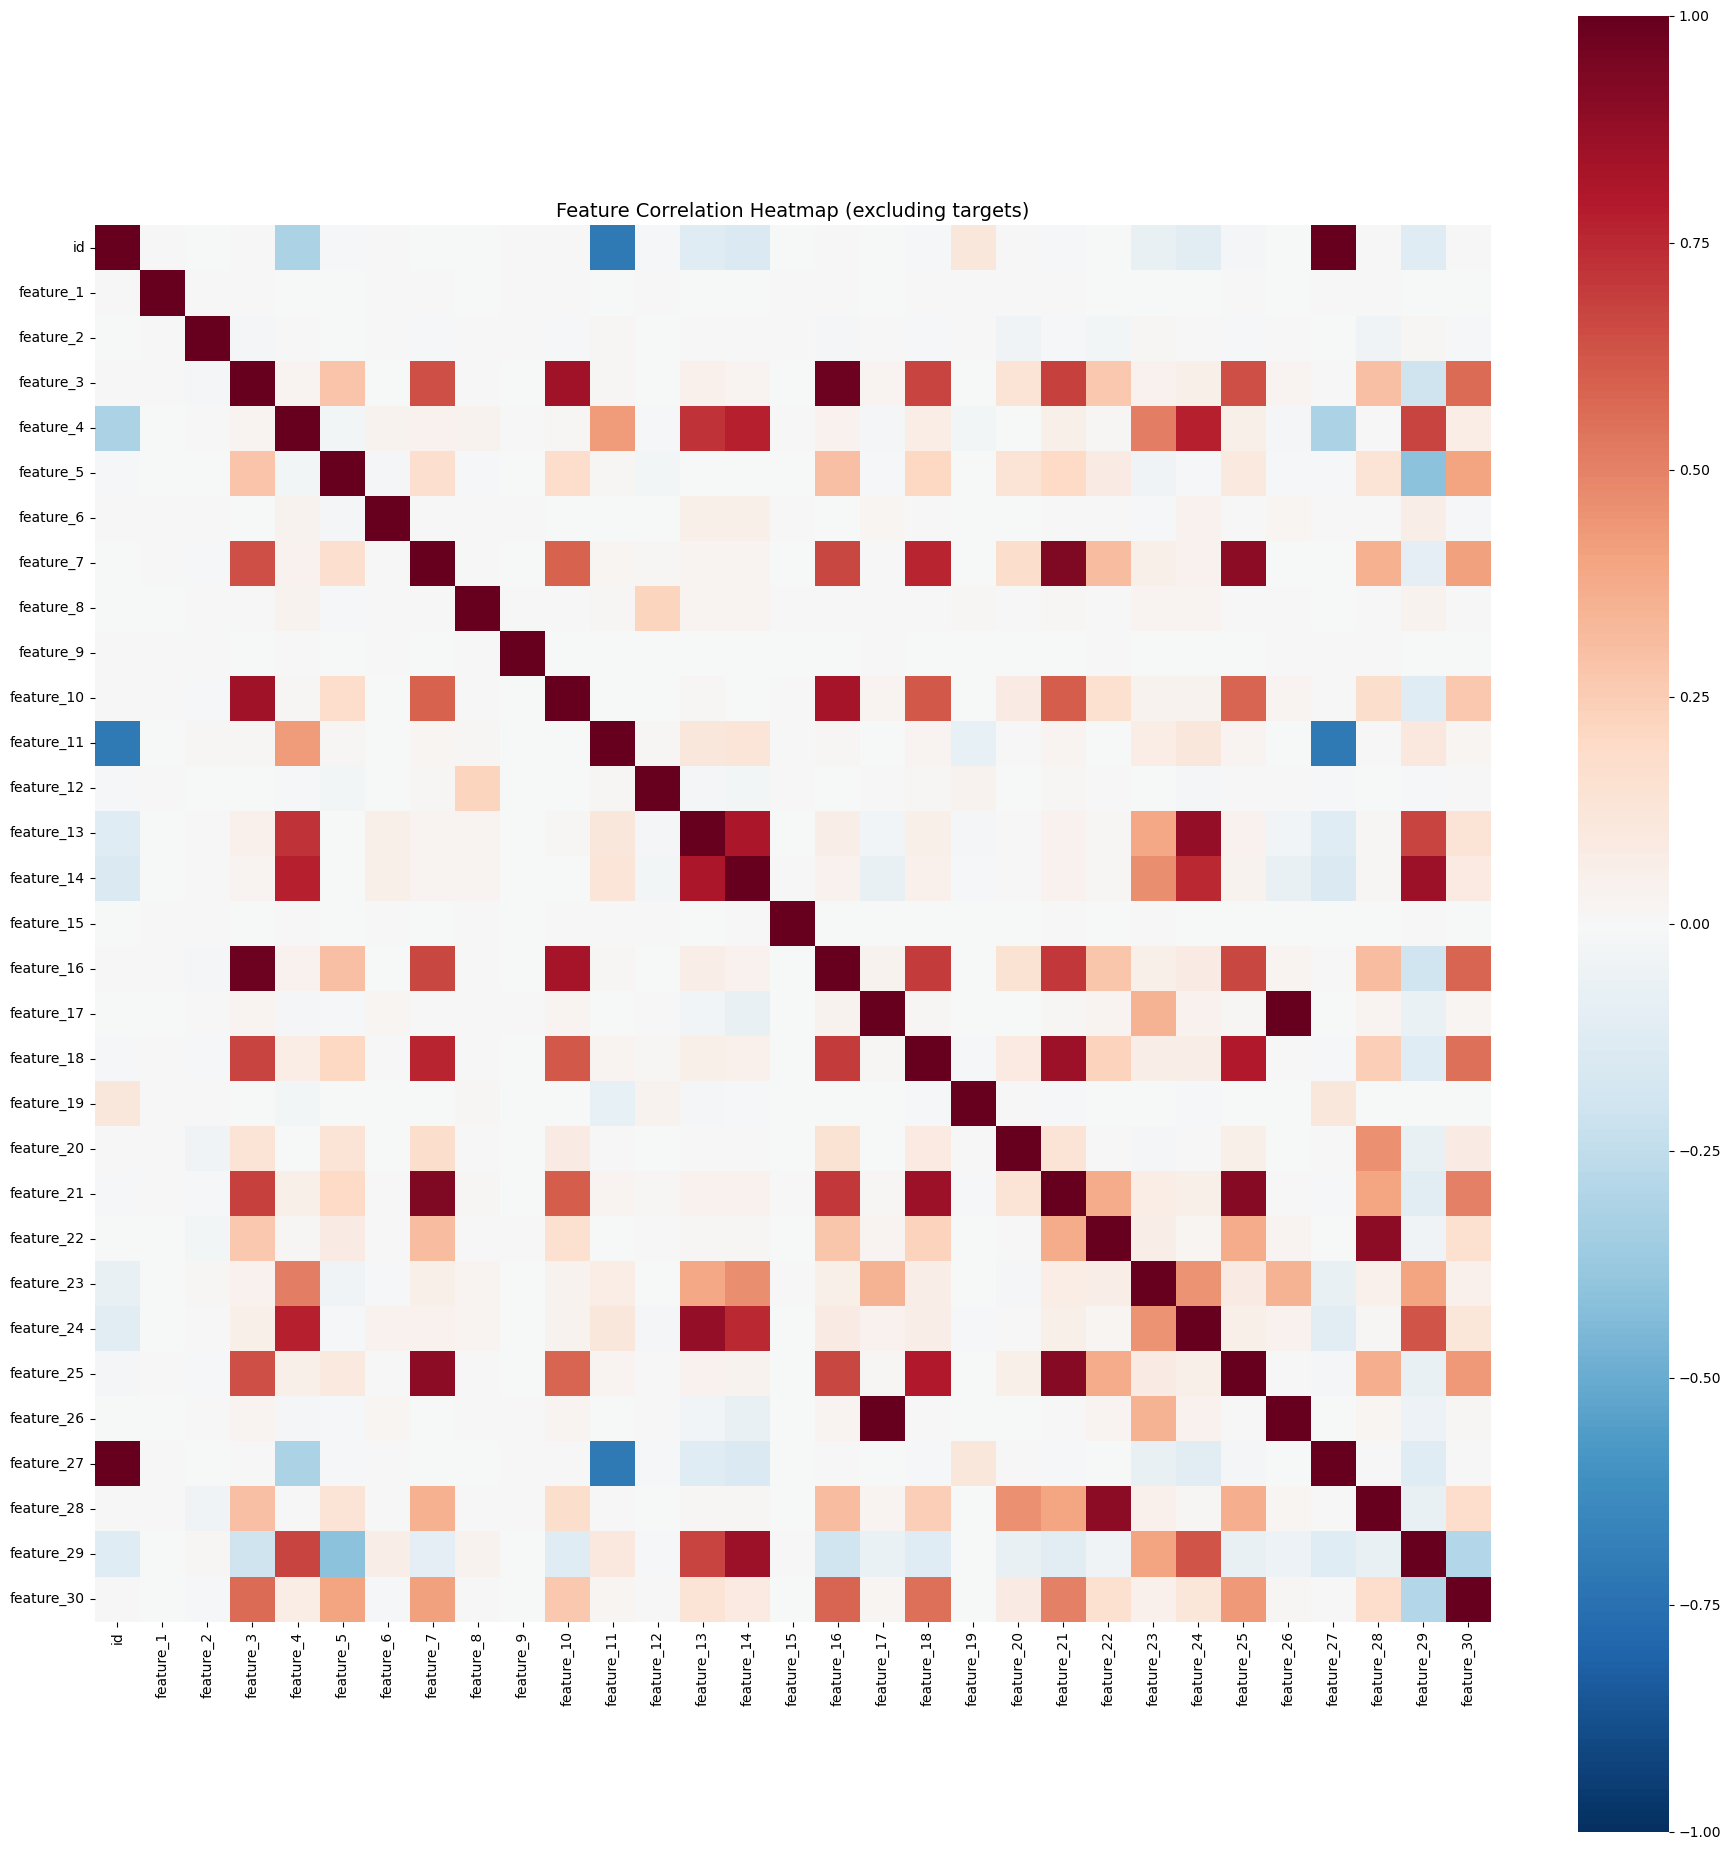

In [ ]:
# Feature Correlation Heatmap (train.csv)
# Excludes columns containing 'target' in their name.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data_path = os.path.join('trademaster25', 'train.csv')
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    
    # Filter numerical columns and exclude 'target' columns
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if 'target' not in c]
    num_df = df[num_cols]

    if num_df.shape[1] > 0:
        corr = num_df.corr()

        # Plot heatmap
        plt.figure(figsize=(min(0.6 * len(num_cols), 15), min(0.6 * len(num_cols), 15)))
        sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True)
        plt.title('Feature Correlation Heatmap (excluding targets)', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("No numerical features found (excluding targets).")
else:
    print(f"Data file not found: {data_path}")

特征图分析结果：
- 典型平稳噪声：`feature_17` 到 `feature_26`, `feature_3`, `feature_5`。
  - Transformer特长
- 离散/类别特征：feature_1 (Image 4): 只有两条横线（可能是 0 和 1，或者 -1 和 1）。feature_6, feature_8, feature_12 (Image 4): 呈现出明显的“分层”条纹。这说明它们不是连续数值，而是某种离散的档位。
  - XGBoost特长
- 非平稳趋势特征: `feature_11`
- 时间泄露特征：`feature_27`， 严格正相关，应该去掉。

# Principal Component Analysis (PCA)
This section performs PCA on the numerical features (excluding targets) to analyze the explained variance ratio.

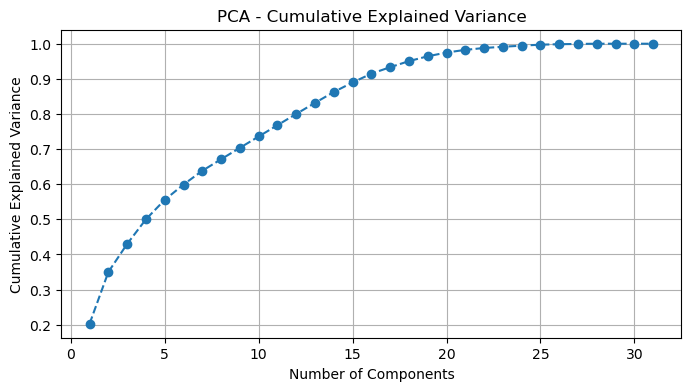

Number of components explaining 95% variance: 18


In [10]:
# Principal Component Analysis (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Use the numerical dataframe 'num_df' prepared in the previous cell
# Handle missing values and infinite values
X = num_df.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Determine number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components explaining 95% variance: {n_components_95}")

Calculated 1st difference for feature_27


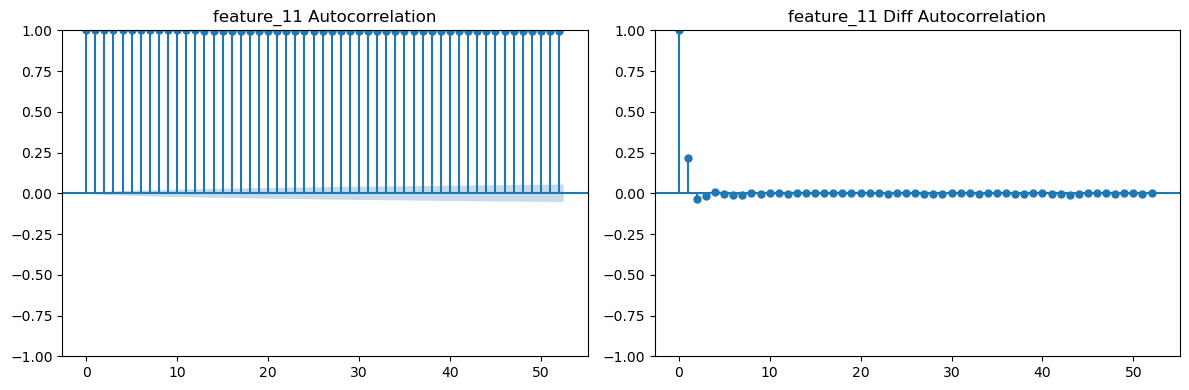

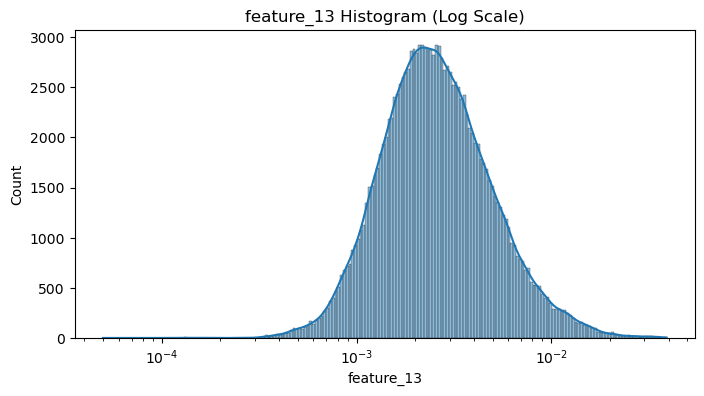

Min value of feature_13: 0.0


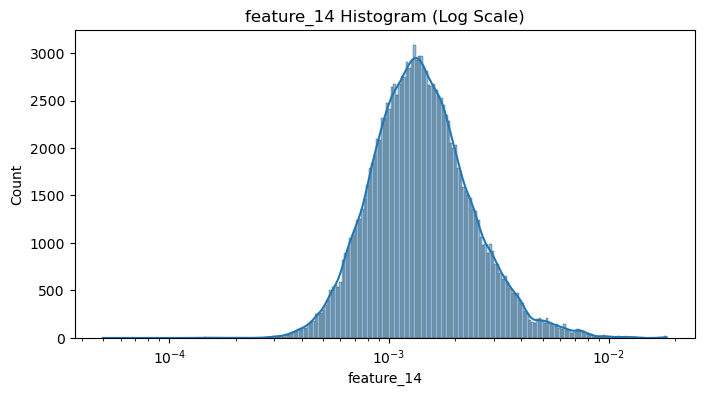

Min value of feature_14: 0.0


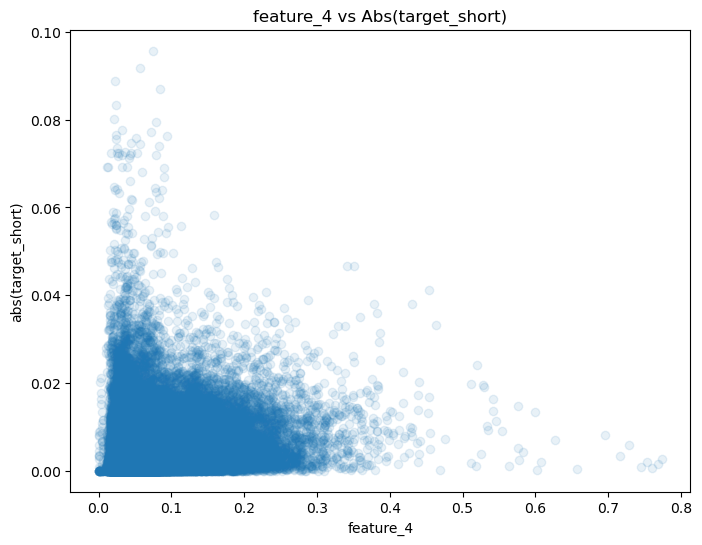

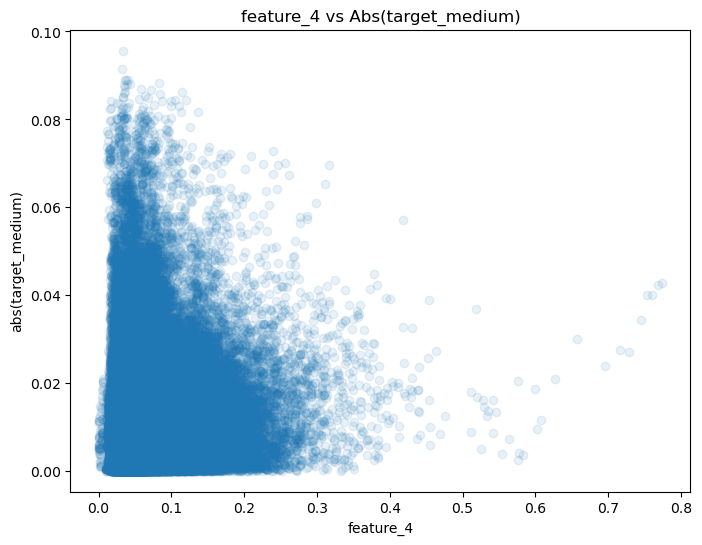

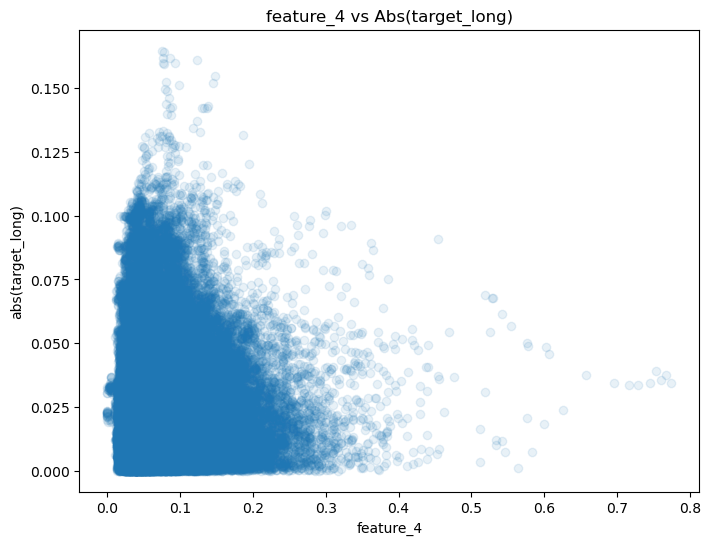


Mean target_long by feature_1:
feature_1
0   -0.000777
1   -0.000672
Name: target_long, dtype: float64


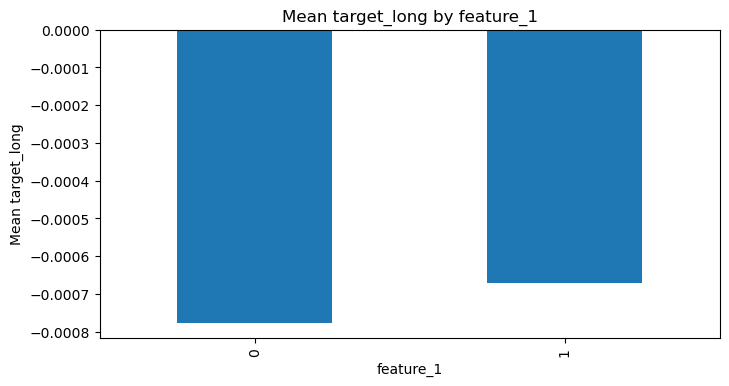


Value Counts for feature_6:
feature_6
-1.904991    581
-1.903163    580
-1.900786    580
-1.897150    581
-1.881808    581
            ... 
 1.880423    580
 1.897965    580
 1.900130    581
 1.903614    581
 1.904696    580
Name: count, Length: 240, dtype: int64


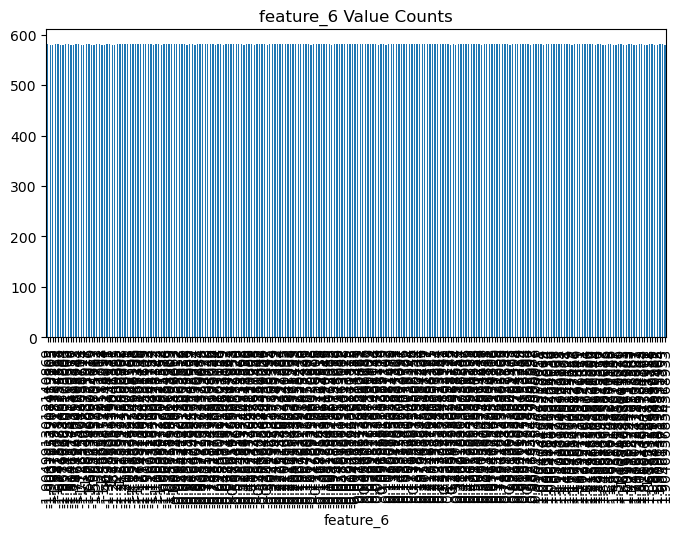


Value Counts for feature_8:
feature_8
-0.900969    28560
-0.900969    28800
-0.222521    27840
 0.623490    27600
 1.000000    26592
Name: count, dtype: int64


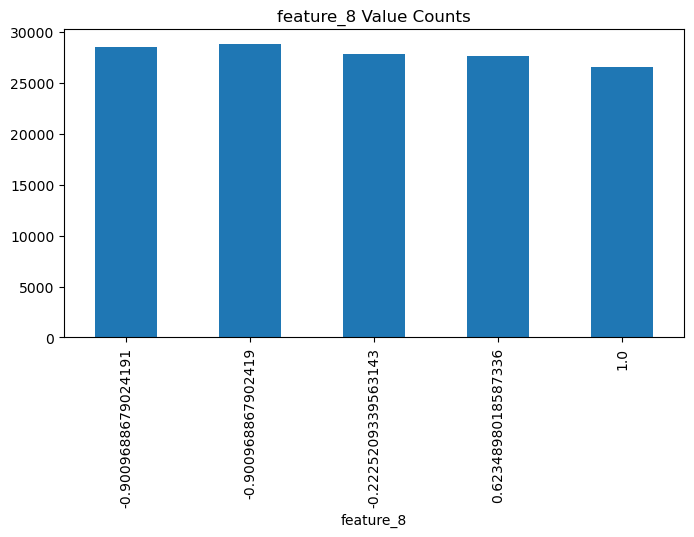


Value Counts for feature_12:
feature_12
-0.433884    28560
 0.000000    26592
 0.433884    28800
 0.781831    27600
 0.974928    27840
Name: count, dtype: int64


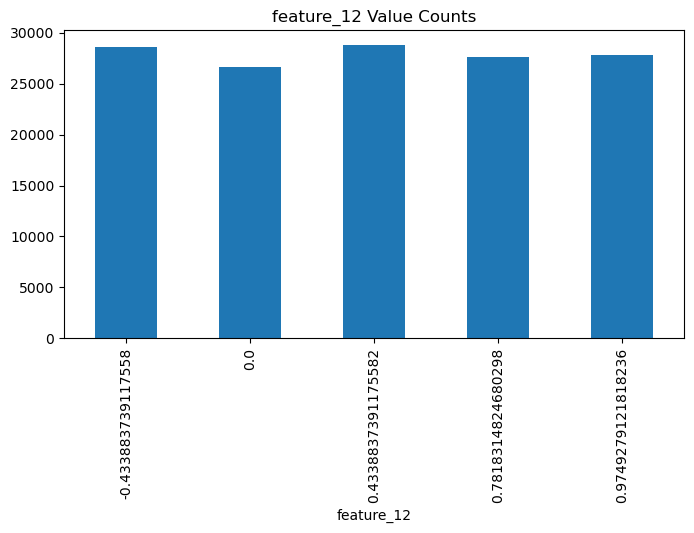

In [14]:
# Feature Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import pandas as pd

# Ensure column names match the dataset
# Assuming columns are named 'feature_00', 'feature_01' etc. or 'feat_00' etc.
# Based on user request, we use 'feature_XX'. If not found, we try to map.

def get_col_name(df, name):
    if name in df.columns:
        return name
    # Try mapping 'feature_XX' to 'feat_XX' or similar if needed
    # For now, assume user provided correct names or we use 'feature_XX'
    return name

# 1. Calculate diff = feature_27[i] - feature_27[i-1]
col_27 = get_col_name(df, 'feature_27')
if col_27 in df.columns:
    df[f'{col_27}_diff'] = df[col_27].diff()
    print(f"Calculated 1st difference for {col_27}")

# 2. feature_11 Autocorrelation and Diff
col_11 = get_col_name(df, 'feature_11')
if col_11 in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(df[col_11].dropna(), ax=axes[0], title=f'{col_11} Autocorrelation')
    
    # First difference
    feat_11_diff = df[col_11].diff().dropna()
    plot_acf(feat_11_diff, ax=axes[1], title=f'{col_11} Diff Autocorrelation')
    plt.tight_layout()
    plt.show()

# 3. feature_13, feature_14 (Bid-Ask Spread Hypothesis)
cols_spread = [get_col_name(df, 'feature_13'), get_col_name(df, 'feature_14')]
for col in cols_spread:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        # Filter positive values for log scale
        data_to_plot = df[col][df[col] > 0]
        sns.histplot(data_to_plot, log_scale=True, kde=True)
        plt.title(f'{col} Histogram (Log Scale)')
        plt.show()
        print(f"Min value of {col}: {df[col].min()}")

# 4. feature_4 vs abs(target)
col_4 = get_col_name(df, 'feature_4')
# Identify target column
target_col = 'target' # Default
if 'target_cols' in locals() and len(target_cols) > 0:
    target_col = target_cols[0]
elif 'target' not in df.columns:
    # Try to find a column with 'target' in name
    targets = [c for c in df.columns if 'target' in c]
    if targets:
        target_col = targets[0]

target_cols = [c for c in df.columns if 'target' in c]

if col_4 in df.columns:
    for target_col in target_cols:
        plt.figure(figsize=(8, 6))
        plt.scatter(df[col_4], df[target_col].abs(), alpha=0.1)
        plt.xlabel(col_4)
        plt.ylabel(f'abs({target_col})')
        plt.title(f'{col_4} vs Abs({target_col})')
        plt.show()

# 5. feature_1 states vs Target Mean
col_1 = get_col_name(df, 'feature_1')
if col_1 in df.columns and target_col in df.columns:
    mean_target = df.groupby(col_1)[target_col].mean()
    print(f"\nMean {target_col} by {col_1}:")
    print(mean_target)
    
    plt.figure(figsize=(8, 4))
    mean_target.plot(kind='bar')
    plt.title(f'Mean {target_col} by {col_1}')
    plt.ylabel(f'Mean {target_col}')
    plt.show()

# 6. Discrete Levels: feature_6, feature_8, feature_12
cols_discrete = [get_col_name(df, 'feature_6'), get_col_name(df, 'feature_8'), get_col_name(df, 'feature_12')]
for col in cols_discrete:
    if col in df.columns:
        print(f"\nValue Counts for {col}:")
        print(df[col].value_counts().sort_index())
        
        plt.figure(figsize=(8, 4))
        df[col].value_counts().sort_index().plot(kind='bar')
        plt.title(f'{col} Value Counts')
        plt.show()

### Analysis Summary

Based on the visualizations and calculations above:

1.  **Feature 27**: 丢弃，防止过拟合
2.  **Feature 11**: ACF（自相关性）在1左右 ->是某种累积指标。一阶拆分类似白噪声 -> price or index level.
    1. 使用diff作为特征。
3.  **Feature 13 & 14**: 呈现对数正态分布（非负性）。 -> bid-ask spread or quote imbalance
4.  **Feature 4 vs Target**: 当feature4很小，target也很小，变大时则target范围变大 -> 异方差性 -> volatility or volume -> 可以构建交叉特征如 `feature_11_diff/feature_4`
5.  **Feature 1**: state 0与1的均值有差异，state1d1平均亏损更小。 -> 可以告诉xgboost他是categorial，或在NN中embedding
6.  **Discrete Features**:
    *   **Feature 8**: Has exactly **5 unique values**, 
    *   **Feature 12**: Has exactly **5 unique values**, 
        *   可能是 tick size group or sector group -> 用one-hot encoding 或者embedding处理
    *   **Feature 6**: Has **240 unique values**. 一天刚好有240个`minute_id` ->通过`z-score`处理后的时间etc. -> time of the day

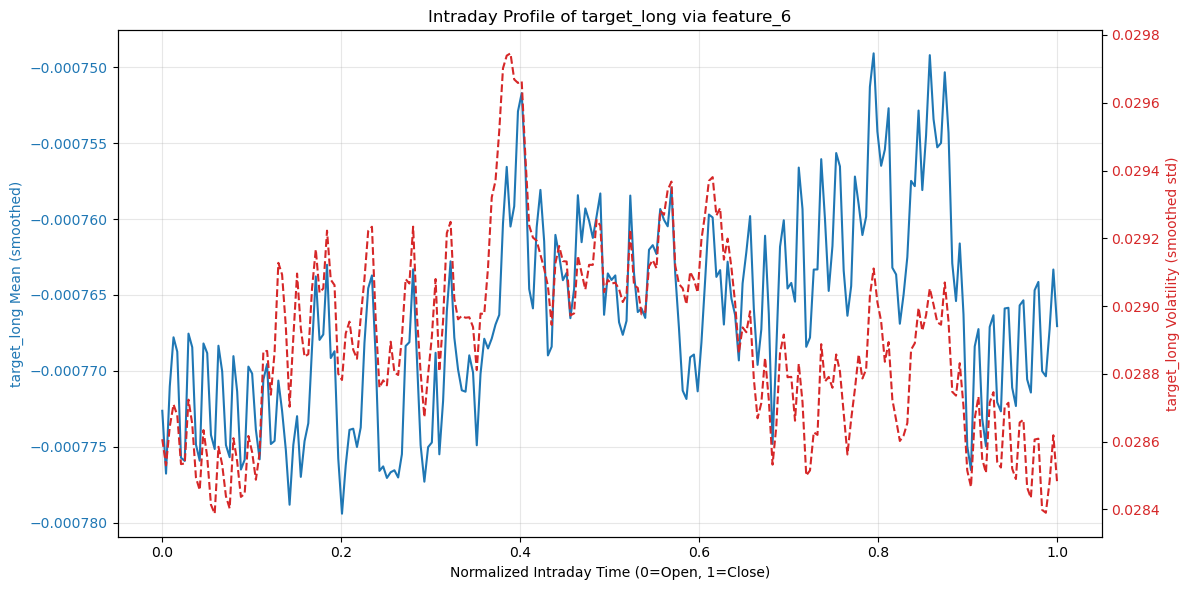

Segment-level averages (mean & std of target):
                   mean       std
segment                          
Open (0-1/3)  -0.000772  0.028825
Mid (1/3-2/3) -0.000764  0.029157
Close (2/3-1) -0.000763  0.028717

Sample buckets (first 5, mid 5, last 5):


,time_rank,time_norm,mean,std
0,0,0.000000,-0.000798,0.028152
1,1,0.004184,-0.000743,0.029253
2,2,0.008368,-0.000744,0.029168
3,3,0.012552,-0.000806,0.027855
4,4,0.016736,-0.000793,0.028222


,time_rank,time_norm,mean,std
118,118,0.493724,-0.000747,0.029368
119,119,0.497908,-0.000781,0.028922
120,120,0.502092,-0.000767,0.029025
121,121,0.506276,-0.000800,0.028060
122,122,0.510460,-0.000752,0.029286


,time_rank,time_norm,mean,std
235,235,0.983264,-0.000748,0.029173
236,236,0.987448,-0.000745,0.029181
237,237,0.991632,-0.000786,0.027834
238,238,0.995816,-0.000792,0.027690
239,239,1.000000,-0.000745,0.029217


In [18]:
# Feature 6 Analysis: Intraday Time Patterns (refined)
# Hypothesis: feature_6 encodes 240 intraday time buckets.
# We compute mean/volatility per bucket, smooth them, and compare early/mid/late segments.

col_6 = get_col_name(df, 'feature_6')
if col_6 in df.columns and target_col in df.columns:
    # Aggregate by feature_6 value
    intraday_stats = (
        df.groupby(col_6)[target_col]
        .agg(['mean', 'std', 'count'])
        .sort_index()
        .reset_index()
        .rename(columns={col_6: 'feature_6_value'})
    )

    # Assign ordinal intraday order (0 ... 239) based on sorted values
    intraday_stats['time_rank'] = intraday_stats['feature_6_value'].rank(method='dense').astype(int) - 1
    intraday_stats = intraday_stats.sort_values('time_rank').reset_index(drop=True)
    intraday_stats['time_norm'] = intraday_stats['time_rank'] / intraday_stats['time_rank'].max()

    # Rolling smoothing to highlight broad patterns
    window = 7  # roughly 3% of the day
    intraday_stats['mean_smooth'] = intraday_stats['mean'].rolling(window, center=True, min_periods=1).mean()
    intraday_stats['std_smooth'] = intraday_stats['std'].rolling(window, center=True, min_periods=1).mean()

    # Plot smoothed mean and volatility against normalized time
    fig, ax1 = plt.subplots(figsize=(12, 6))
    color = 'tab:blue'
    ax1.set_xlabel('Normalized Intraday Time (0=Open, 1=Close)')
    ax1.set_ylabel(f'{target_col} Mean (smoothed)', color=color)
    ax1.plot(intraday_stats['time_norm'], intraday_stats['mean_smooth'], color=color, label='Mean Target (smooth)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel(f'{target_col} Volatility (smoothed std)', color=color)
    ax2.plot(intraday_stats['time_norm'], intraday_stats['std_smooth'], color=color, linestyle='--', label='Volatility (smooth)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Intraday Profile of {target_col} via {col_6}')
    fig.tight_layout()
    plt.show()

    # Segment into thirds: open, mid, close
    intraday_stats['segment'] = pd.cut(
        intraday_stats['time_norm'],
        bins=[-0.001, 1/3, 2/3, 1.0],
        labels=['Open (0-1/3)', 'Mid (1/3-2/3)', 'Close (2/3-1)']
    )
    segment_summary = intraday_stats.groupby('segment')[['mean', 'std']].mean()
    print('Segment-level averages (mean & std of target):')
    print(segment_summary)

    # Display first/middle/last few buckets for reference
    print('\nSample buckets (first 5, mid 5, last 5):')
    display(intraday_stats[['time_rank', 'time_norm', 'mean', 'std']].head(5))
    mid_start = intraday_stats.shape[0] // 2 - 2
    display(intraday_stats[['time_rank', 'time_norm', 'mean', 'std']].iloc[mid_start:mid_start+5])
    display(intraday_stats[['time_rank', 'time_norm', 'mean', 'std']].tail(5))
else:
    print(f"Columns {col_6} or {target_col} not found.")

In [19]:
# Summaries for early / mid / late segments
if 'intraday_stats' in locals():
    print('\nVolatility (Std) - Opening 5 buckets:')
    print(intraday_stats[['time_rank', 'std']].head(5))

    mid_start = intraday_stats.shape[0] // 2 - 2
    print('\nVolatility (Std) - Mid 5 buckets:')
    print(intraday_stats[['time_rank', 'std']].iloc[mid_start:mid_start+5])

    print('\nVolatility (Std) - Closing 5 buckets:')
    print(intraday_stats[['time_rank', 'std']].tail(5))


Volatility (Std) - Opening 5 buckets:
   time_rank       std
0          0  0.028152
1          1  0.029253
2          2  0.029168
3          3  0.027855
4          4  0.028222

Volatility (Std) - Mid 5 buckets:
     time_rank       std
118        118  0.029368
119        119  0.028922
120        120  0.029025
121        121  0.028060
122        122  0.029286

Volatility (Std) - Closing 5 buckets:
     time_rank       std
235        235  0.029173
236        236  0.029181
237        237  0.027834
238        238  0.027690
239        239  0.029217


2. 折线图深度解读：三个关键的市场时刻请仔细看 image_398b87.jpg，这张图的信息密度极高：

A. 0.35-0.40 处的“神秘剧变” (The Mid-Morning Shock)现象：红色虚线（波动率）：在 x轴 0.35 - 0.40 处有一个突兀的、巨大的尖峰。蓝色实线（收益均值）：同时也伴随着均值的剧烈抖动。时间推算：$0.375 \times 240 \text{分钟} = 90 \text{分钟}$。假设美股 9:30 开盘，90分钟后是 11:00 AM。金融逻辑推测：欧洲股市收盘（European Close）：通常在美股上午 11:30 左右（取决于夏令时），这会带来巨大的流动性变化。宏观数据发布：很多美国经济数据在 10:00 AM 或 10:30 AM 发布，经过一小时消化后，市场可能进入新的博弈阶段。策略启示：在这个时间窗口（minutes_id 85-100），市场风险极高（预测方差大）。你的模型可能需要在这个时间段降低仓位或增加正则化。

B. 0.80 之后的“尾盘效应” (Late Day Alpha)现象：看蓝色实线。在 0.8 (约 192分钟) 之前，均值主要在 -0.00077 以下震荡。在 0.8 之后，蓝色线条明显向上跃升，并在高位震荡。虽然均值还是负的（这很正常，因为包含手续费等），但明显比早盘和中盘要“好”很多。金融逻辑推测：MOC (Market On Close) Flows：在临近收盘的最后一小时（3:00 PM - 4:00 PM），机构投资者和 ETF 会进行大规模的再平衡（Rebalancing）。这些资金流通常是有方向性且巨大的，导致趋势性更强，噪音相对减少。策略启示：尾盘更容易预测。你的模型应该赋予 feature_6 > 0.8 的样本更高的权重，或者专门为尾盘训练一个子模型。

C. 早盘的“无头苍蝇” (Noisy Open)现象：0.0 - 0.2 区间，蓝色线（均值）上下翻飞，没有任何规律，像心电图一样乱跳。金融逻辑：这是典型的**价格发现（Price Discovery）**阶段。昨晚的新闻、情绪都在这一刻宣泄。由于多空博弈极其激烈且缺乏共识，导致预测非常困难（信噪比极低）。3. 如何利用这个发现修改你的特征工程？既然看出了这些规律，就不要只把 feature_6 当作一个 Embedding 扔进去了，你可以构造更强的人工特征：构造“关键时间点”特征：is_european_close = 1 if (feature_6 >= 85 and feature_6 <= 100) else 0is_late_session = 1 if feature_6 >= 190 else 0让树模型（XGBoost）明确知道这些特殊时间段。交互特征 (Interaction)：feature_4 (Volatility) * is_late_session：尾盘的高波动率往往意味着趋势（Smart Money 进场）。早盘的高波动率往往意味着分歧（Dumb Money 互搏）。让模型区分这两种波动的不同含义。加权策略 (Sample Weighting)：在训练时，可以尝试给 feature_6 > 190 的样本稍微大一点的权重，因为图表显示这段时间的信号更清晰（蓝色线更高），是主要的得分来源。总结这组图证明了 feature_6 不是线性的。市场在一天中经历了三个阶段：早盘 (0.0-0.3)：混乱博弈，难以预测。转折期 (0.35-0.4)：受欧洲收盘或宏观数据冲击，波动率激增。尾盘 (0.8-1.0)：机构调仓，信号质量变好（Mean Target 提升）。

### Test 数据feature可视化
查看大致范围

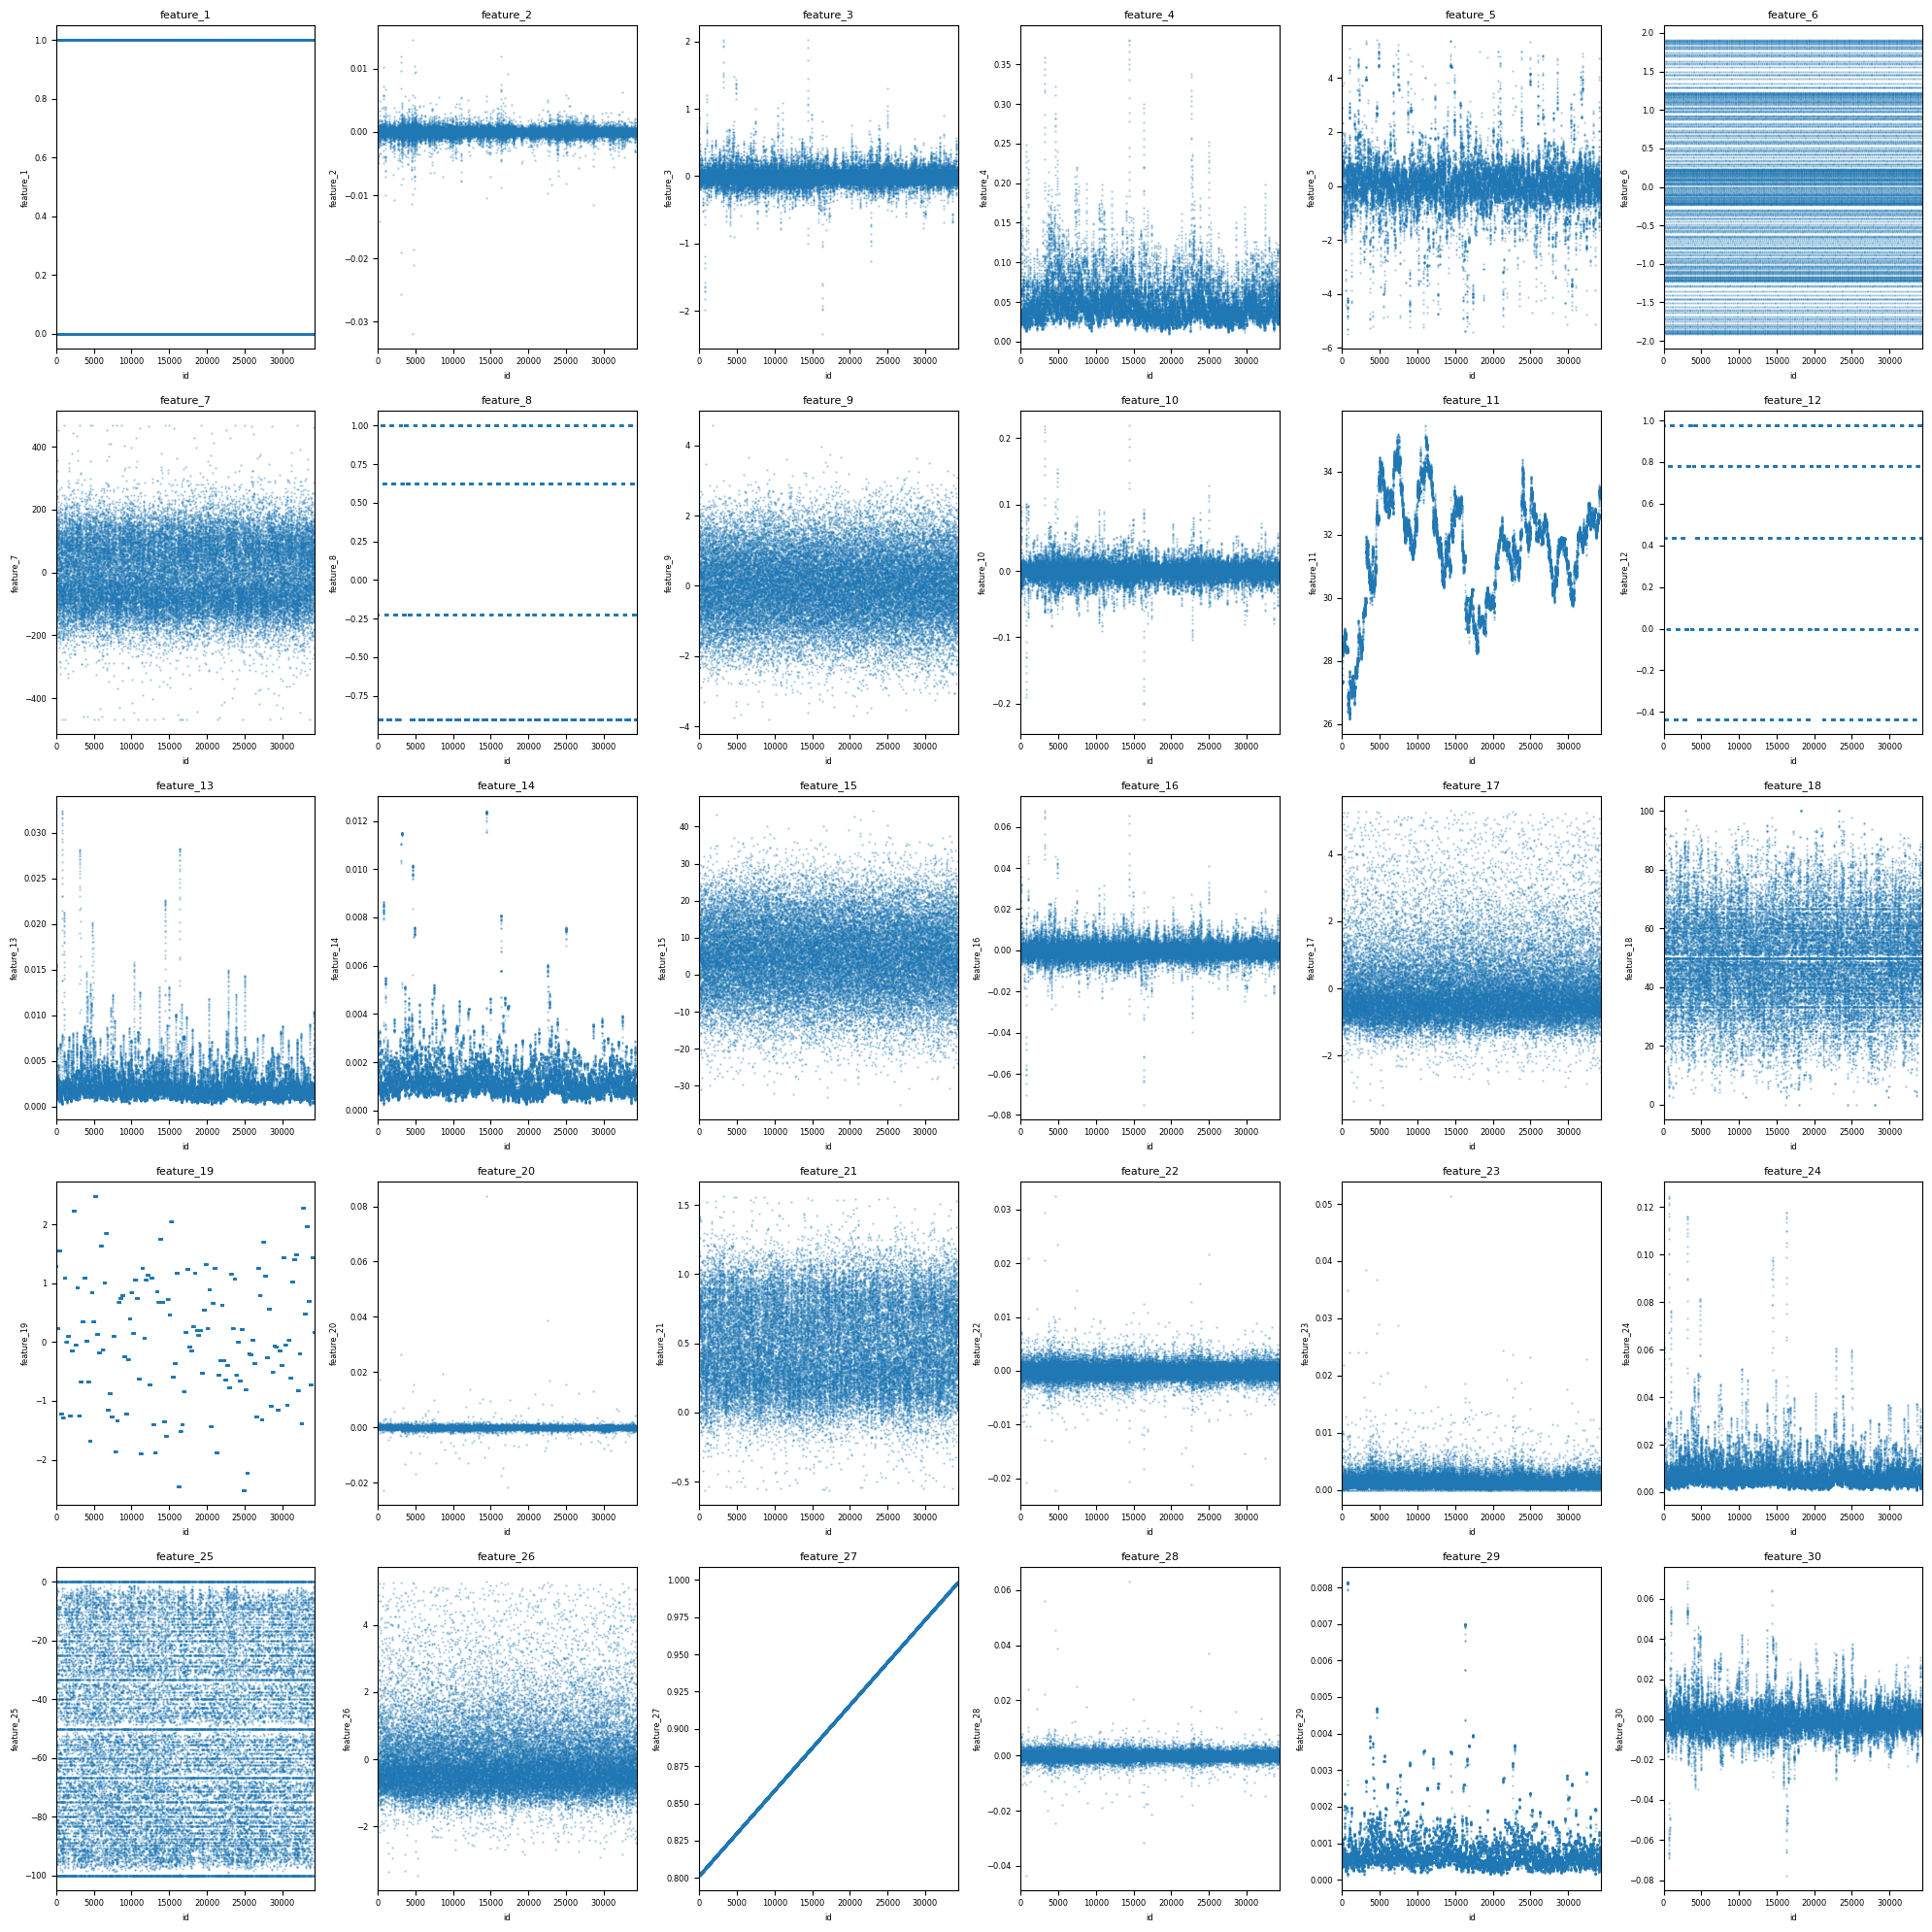

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature and target columns
features = [c for c in test_df.columns if c.startswith('feature')]

# Get minute_id range
min_minute = test_df['minute_id'].min()
max_minute = test_df['minute_id'].max()

# Plot all features in one figure
n_features = len(features)
n_cols = 6
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, f in enumerate(features):
    axes[i].scatter(test_df['id'], test_df[f], alpha=0.3, s=0.5)
    axes[i].set_title(f, fontsize=8)
    axes[i].set_xlabel('id', fontsize=6)
    axes[i].set_ylabel(f, fontsize=6)
    axes[i].set_xlim(0, test_df['id'].max())
    axes[i].tick_params(labelsize=6)

# Hide unused subplots
for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Feature Analysis and Visualization
This section includes various analyses and visualizations for specific features as requested:
1. Difference calculation for `feature_27`.
2. Autocorrelation plot for `feature_11`.
3. Histogram analysis for `feature_13` and `feature_14` (Bid-Ask Spread hypothesis).
4. Scatter plot of `feature_4` vs `abs(target)`.
5. Mean target value for each state of `feature_1`.
6. Value counts for discrete features `feature_6`, `feature_8`, and `feature_12`.

PCA结果：18个主成分可以解释95%的方差。不需要用到全部30个特征，做降维处理。
- 可以使用AutoEncoder：一种非线性的PCA进行数据降维，这张图证明这样的降维导致损失的信息很少。

4.1.1 探索性数据分析 (EDA)
1. 分布检验：偏度 (Skewness) 和 峰度 (Kurtosis)

特征分布统计摘要:
         Skewness   Kurtosis
count   29.000000  29.000000
unique  29.000000  29.000000
top      2.654684   5.047422
freq     1.000000   1.000000

峰度 > 3 的特征数量: 17 / 30
分析: 数据呈现明显的'尖峰厚尾' (Leptokurtic) 特征。
结论: 这证实了 GaussRank 的必要性，以缓解极端值对模型的影响。

2. 相关性分析 (Spearman)


4.1.1 探索性数据分析 (EDA)
1. 分布检验：偏度 (Skewness) 和 峰度 (Kurtosis)

特征分布统计摘要:
         Skewness   Kurtosis
count   29.000000  29.000000
unique  29.000000  29.000000
top      2.654684   5.047422
freq     1.000000   1.000000

峰度 > 3 的特征数量: 17 / 30
分析: 数据呈现明显的'尖峰厚尾' (Leptokurtic) 特征。
结论: 这证实了 GaussRank 的必要性，以缓解极端值对模型的影响。

2. 相关性分析 (Spearman)


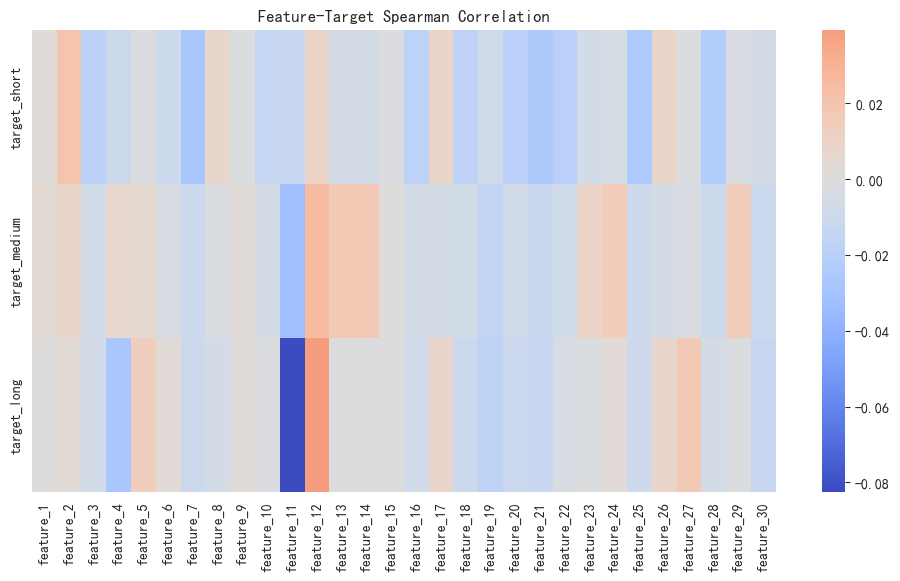

4.1.1 探索性数据分析 (EDA)
1. 分布检验：偏度 (Skewness) 和 峰度 (Kurtosis)

特征分布统计摘要:
         Skewness   Kurtosis
count   29.000000  29.000000
unique  29.000000  29.000000
top      2.654684   5.047422
freq     1.000000   1.000000

峰度 > 3 的特征数量: 17 / 30
分析: 数据呈现明显的'尖峰厚尾' (Leptokurtic) 特征。
结论: 这证实了 GaussRank 的必要性，以缓解极端值对模型的影响。

2. 相关性分析 (Spearman)


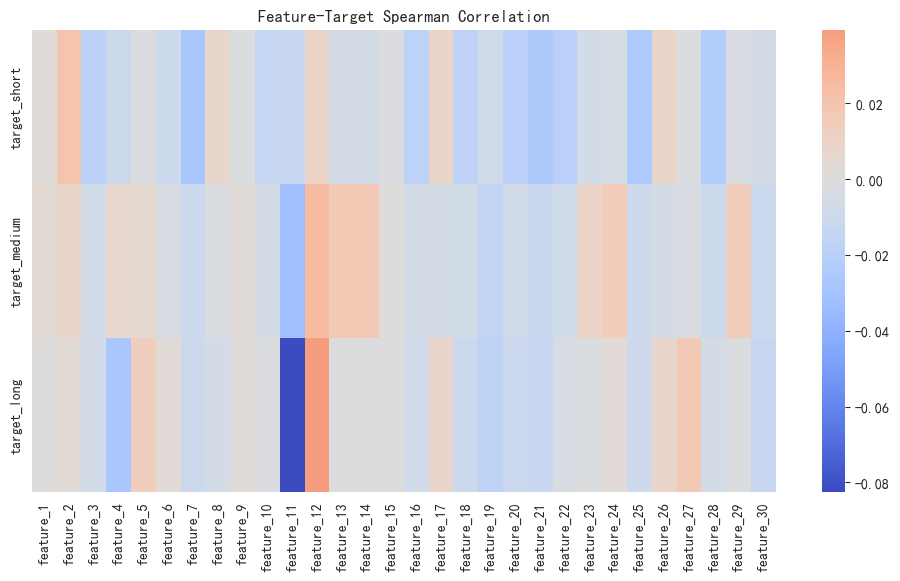


3. 自相关性 (ACF/PACF)


4.1.1 探索性数据分析 (EDA)
1. 分布检验：偏度 (Skewness) 和 峰度 (Kurtosis)

特征分布统计摘要:
         Skewness   Kurtosis
count   29.000000  29.000000
unique  29.000000  29.000000
top      2.654684   5.047422
freq     1.000000   1.000000

峰度 > 3 的特征数量: 17 / 30
分析: 数据呈现明显的'尖峰厚尾' (Leptokurtic) 特征。
结论: 这证实了 GaussRank 的必要性，以缓解极端值对模型的影响。

2. 相关性分析 (Spearman)


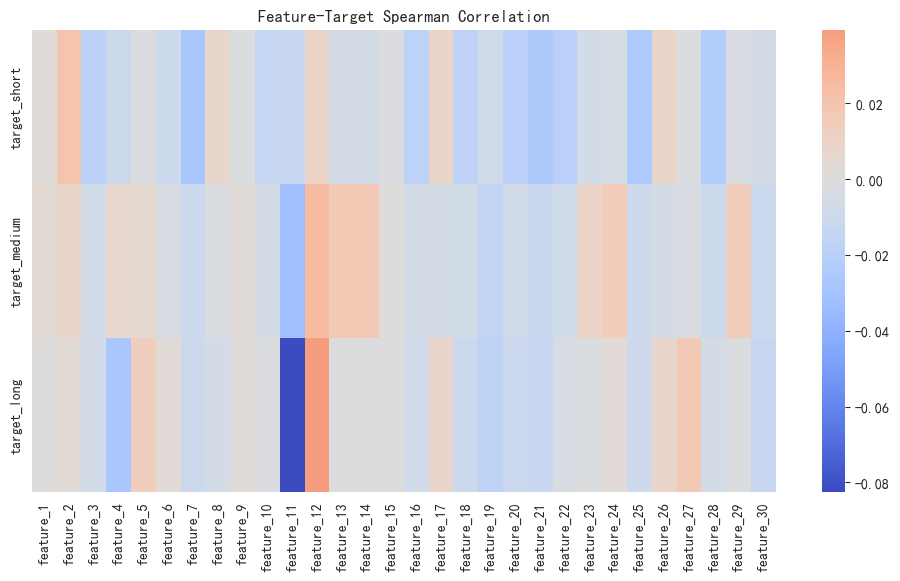


3. 自相关性 (ACF/PACF)


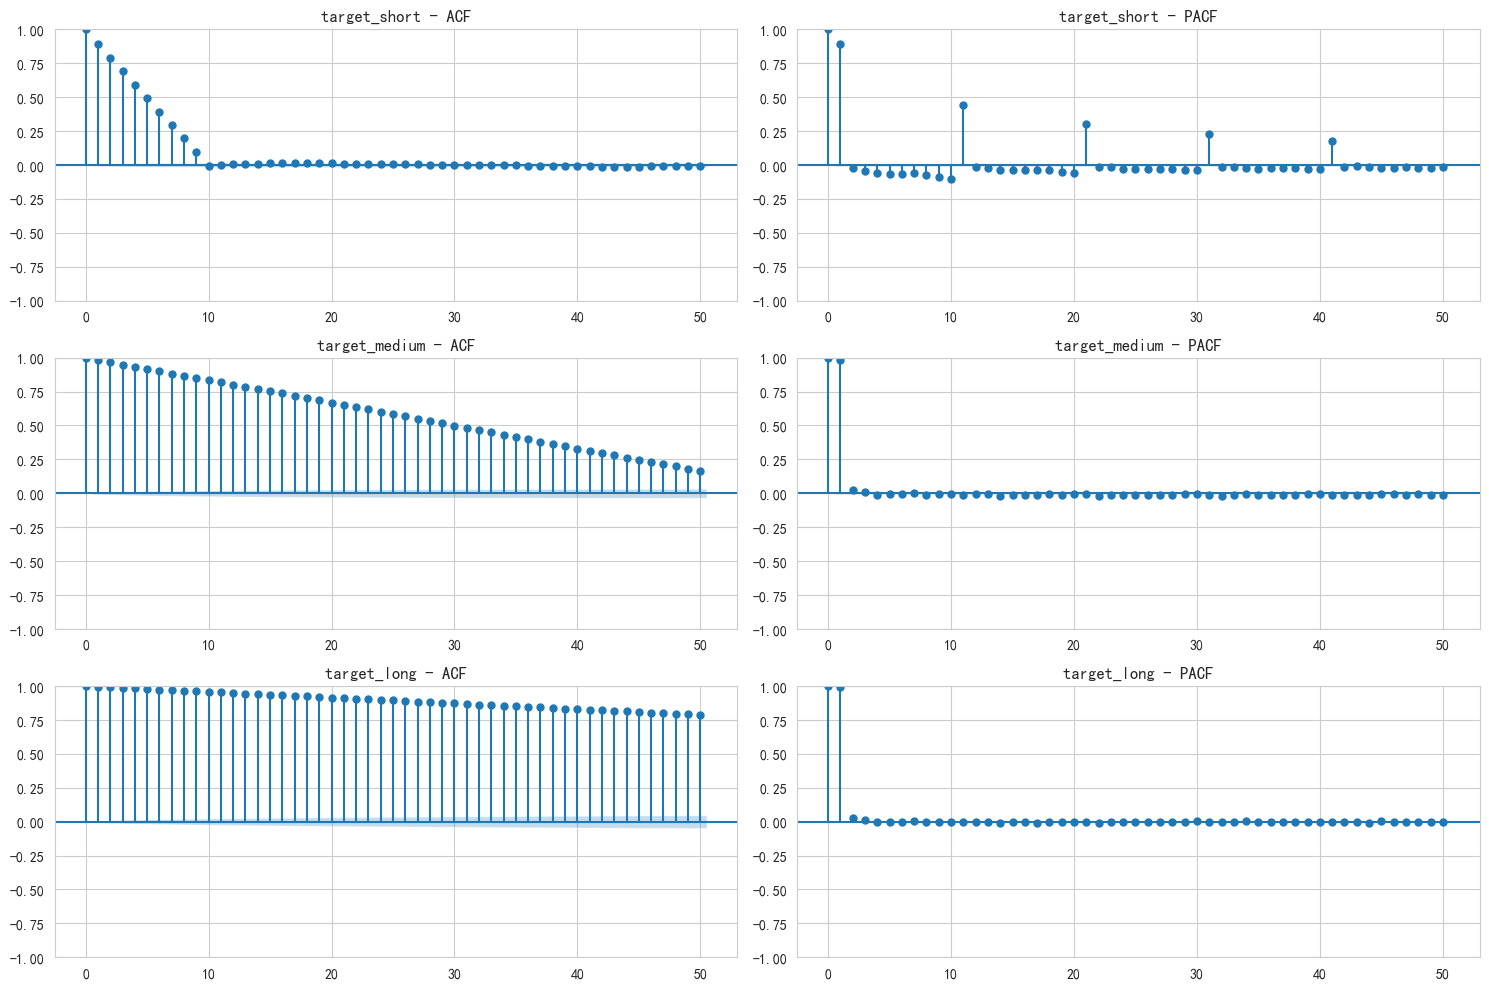

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 设置绘图风格和字体
sns.set_style("whitegrid")
# 尝试多种字体以兼容不同系统
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("4.1.1 探索性数据分析 (EDA)")
print("=" * 80)

# 1. 分布检验
print("1. 分布检验：偏度 (Skewness) 和 峰度 (Kurtosis)")
dist_stats = pd.DataFrame(index=feature_cols, columns=['Skewness', 'Kurtosis'])
for col in feature_cols:
    dist_stats.loc[col, 'Skewness'] = train_df[col].skew()
    dist_stats.loc[col, 'Kurtosis'] = train_df[col].kurtosis()

print("\n特征分布统计摘要:")
print(dist_stats.describe())

# 检查尖峰厚尾
high_kurtosis = dist_stats[dist_stats['Kurtosis'] > 3]
print(f"\n峰度 > 3 的特征数量: {len(high_kurtosis)} / {len(feature_cols)}")
if len(high_kurtosis) > 0:
    print("分析: 数据呈现明显的'尖峰厚尾' (Leptokurtic) 特征。")
    print("结论: 这证实了 GaussRank 的必要性，以缓解极端值对模型的影响。")

# 2. 相关性分析
print("\n" + "=" * 80)
print("2. 相关性分析 (Spearman)")
corr_spearman = train_df[feature_cols + target_cols].corr(method='spearman')
target_corr = corr_spearman.loc[feature_cols, target_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(target_corr.T, cmap='coolwarm', center=0, annot=False)
plt.title('Feature-Target Spearman Correlation')
plt.show()

# 3. 自相关性 (ACF/PACF)
print("\n" + "=" * 80)
print("3. 自相关性 (ACF/PACF)")
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
for i, target in enumerate(target_cols):
    plot_acf(train_df[target], lags=50, ax=axes[i, 0], title=f'{target} - ACF')
    plot_pacf(train_df[target], lags=50, ax=axes[i, 1], title=f'{target} - PACF')
plt.tight_layout()
plt.show()


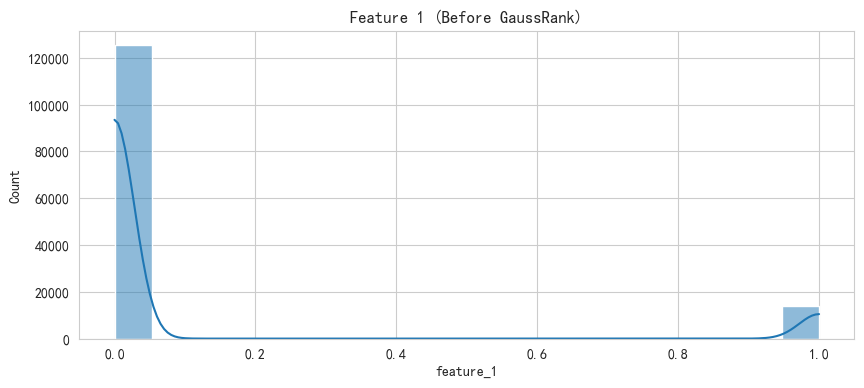

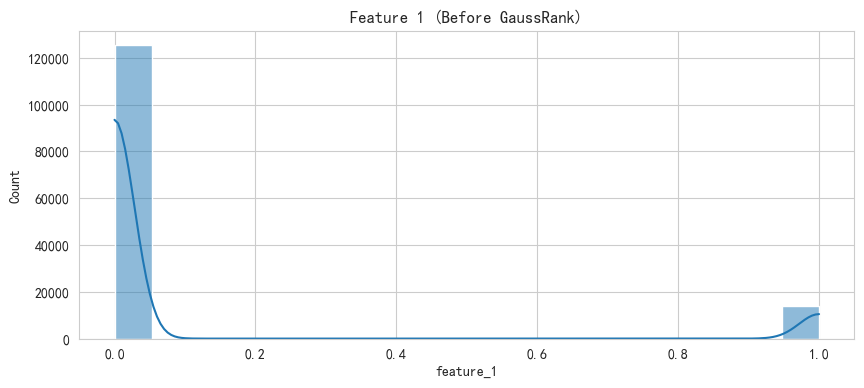

4.1.2 GaussRank 归一化 (Rank-Gauss)
Applying GaussRank normalization...
GaussRank normalization complete.

归一化后的偏度和峰度 (前5个特征):
          feature_1  feature_2  feature_3  feature_4  feature_5
skew       2.654684   0.010780  -0.031259   0.000651  -0.008955
kurtosis   5.047422   5.505653   5.551395   5.514407   5.330535


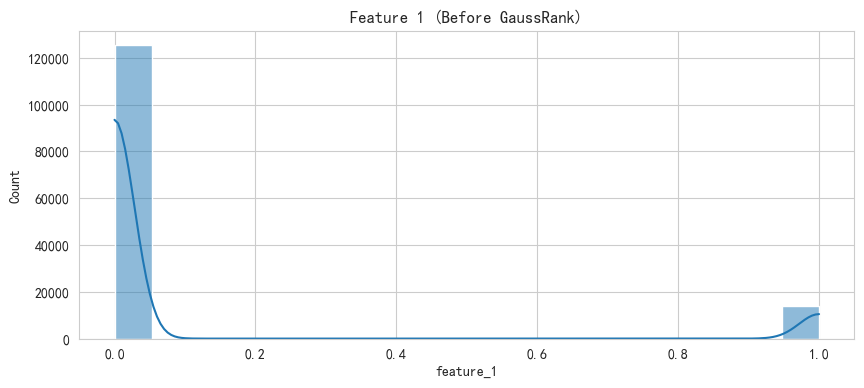

4.1.2 GaussRank 归一化 (Rank-Gauss)
Applying GaussRank normalization...
GaussRank normalization complete.

归一化后的偏度和峰度 (前5个特征):
          feature_1  feature_2  feature_3  feature_4  feature_5
skew       2.654684   0.010780  -0.031259   0.000651  -0.008955
kurtosis   5.047422   5.505653   5.551395   5.514407   5.330535


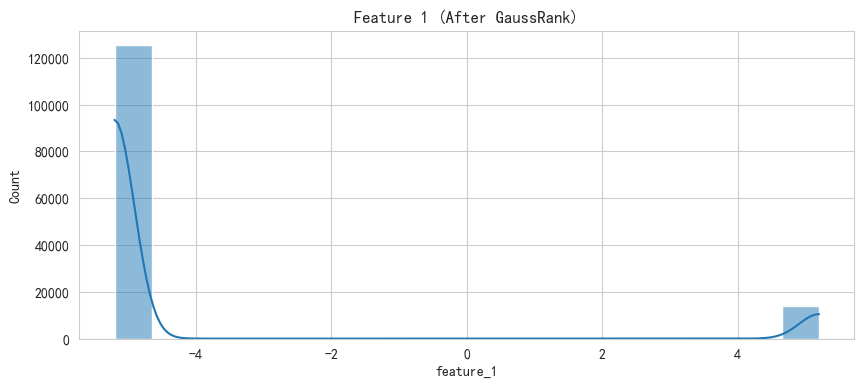

In [43]:
# 可视化第一个特征的分布变化
plt.figure(figsize=(10, 4))
sns.histplot(train_df['feature_1'], kde=True)
plt.title('Feature 1 (Before GaussRank)')
plt.show()

from sklearn.preprocessing import QuantileTransformer

print("4.1.2 GaussRank 归一化 (Rank-Gauss)")
print("=" * 80)

# 使用 QuantileTransformer 进行 GaussRank 归一化
# output_distribution='normal' 将数据映射为高斯分布
gauss_scaler = QuantileTransformer(output_distribution='normal', random_state=42)

print("Applying GaussRank normalization...")
# 对特征列进行转换
train_df[feature_cols] = gauss_scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = gauss_scaler.transform(test_df[feature_cols])

print("GaussRank normalization complete.")

# 验证归一化后的分布
print("\n归一化后的偏度和峰度 (前5个特征):")
print(train_df[feature_cols[:5]].agg(['skew', 'kurtosis']))

# 可视化第一个特征的分布变化
plt.figure(figsize=(10, 4))
sns.histplot(train_df['feature_1'], kde=True)
plt.title('Feature 1 (After GaussRank)')
plt.show()

In [45]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import pickle

print("4.1.3 Purged Group Time Series Split (核心验证策略)")
print("=" * 80)

class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=5, gap=0):
        self.n_splits = n_splits
        self.gap = gap

    def split(self, X, y=None, groups=None):
        if groups is None:
            tscv = TimeSeriesSplit(n_splits=self.n_splits)
            for train_idx, test_idx in tscv.split(X):
                test_start = test_idx[0]
                train_end_limit = test_start - self.gap
                train_idx_purged = train_idx[train_idx <= train_end_limit]
                if len(train_idx_purged) > 0:
                    yield train_idx_purged, test_idx
        else:
            unique_groups = np.unique(groups)
            unique_groups.sort()
            tscv = TimeSeriesSplit(n_splits=self.n_splits)
            for train_groups_idx, test_groups_idx in tscv.split(unique_groups):
                train_groups = unique_groups[train_groups_idx]
                test_groups = unique_groups[test_groups_idx]
                
                test_start_group_idx = test_groups_idx[0]
                train_end_group_idx_limit = test_start_group_idx - self.gap
                train_groups_idx_purged = train_groups_idx[train_groups_idx <= train_end_group_idx_limit]
                
                if len(train_groups_idx_purged) > 0:
                    train_groups_purged = unique_groups[train_groups_idx_purged]
                    train_idx = np.where(np.isin(groups, train_groups_purged))[0]
                    test_idx = np.where(np.isin(groups, test_groups))[0]
                    yield train_idx, test_idx

# --- 策略配置 ---
# 1. Grouping: 使用 date_id (天)
#    理由: 即使有 minutes_id，按天分组能更彻底地防止日内微观结构噪音的泄露，且计算效率更高。
# 2. Gap: 取决于预测目标的最长跨度
#    理由: 如果同时预测"几分钟后"(Short)和"几天后"(Long)，必须使用覆盖 Long 的 Gap。
#    例如: Long 是预测 5 天后的收益率，那么 Gap 至少要设为 5 (天)。
#    虽然这对 Short 目标来说 Gap 过大（浪费了一些近期数据），但能确保验证集的绝对安全（无泄露）。

N_SPLITS = 5
# 假设 date_id 是连续的整数代表天数
# 假设 target_long 预测未来 5 天，则设置 GAP = 5 + 1 (缓冲) = 6
GAP = 6 

# 检查并设置 Groups
groups = None
if 'date_id' in train_df.columns:
    groups = train_df['date_id'].values
    print(f"✅ 使用 'date_id' 进行分组 (Groups: {len(np.unique(groups))} days)")
    print(f"✅ 设置 Gap = {GAP} (days) 以覆盖最长预测窗口")
else:
    print("no 'date_id' column found for grouping. Using standard TimeSeriesSplit.")

cv = PurgedGroupTimeSeriesSplit(n_splits=N_SPLITS, gap=GAP)

# 生成并保存分割
splits = []
for train_idx, test_idx in cv.split(train_df, groups=groups):
    splits.append((train_idx, test_idx))

with open('cv_splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

print(f"\n已生成 {len(splits)} 折交叉验证分割。")
print(f"分割方案已保存至: cv_splits.pkl")

# 打印第一折的详细信息用于检查
if len(splits) > 0:
    train_idx_0, test_idx_0 = splits[0]
    print("\n--- Fold 1 详情 ---")
    print(f"Train samples: {len(train_idx_0):,}")
    print(f"Test samples:  {len(test_idx_0):,}")
    if groups is not None:
        print(f"Train dates: {groups[train_idx_0].min()} -> {groups[train_idx_0].max()}")
        print(f"Test dates:  {groups[test_idx_0].min()} -> {groups[test_idx_0].max()}")
        print(f"Gap 验证: Test Start ({groups[test_idx_0].min()}) - Train End ({groups[train_idx_0].max()}) = {groups[test_idx_0].min() - groups[train_idx_0].max()}")

4.1.3 Purged Group Time Series Split (核心验证策略)
✅ 使用 'date_id' 进行分组 (Groups: 581 days)
✅ 设置 Gap = 6 (days) 以覆盖最长预测窗口

已生成 5 折交叉验证分割。
分割方案已保存至: cv_splits.pkl

--- Fold 1 详情 ---
Train samples: 23,040
Test samples:  23,040
Train dates: 0 -> 95
Test dates:  101 -> 196
Gap 验证: Test Start (101) - Train End (95) = 6


In [ ]:
import cudf
import cuml
from cuml.neighbors import NearestNeighbors
from cuml.preprocessing import StandardScaler as cuStandardScaler
import numpy as np
import pandas as pd
import gc
import pickle

print("4.2 阶段二：RAPIDS 加速的特征工程 (Train + Test)")
print("=" * 80)

# 准备数据 (转换为 GPU DataFrame)
print("Preparing data for GPU...")
X_all = train_df[feature_cols].values
y_all = train_df[target_cols].values
X_test_all = test_df[feature_cols].values # Test set

# 定义 KNN 参数
K_VALUES = [5, 10, 20]
METRICS = ['euclidean', 'cosine']

# 初始化结果容器
n_samples = len(train_df)
n_test_samples = len(test_df)
n_knn_features = len(K_VALUES) * len(METRICS) * (1 + len(target_cols)) 
knn_feature_names = []
knn_features = np.zeros((n_samples, n_knn_features), dtype=np.float32)
knn_features_test = np.zeros((n_test_samples, n_knn_features), dtype=np.float32)

print(f"Generating {n_knn_features} KNN features...")

# 加载之前保存的 splits
with open('cv_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

knn_features[:] = np.nan

# --- Part 1: Generate KNN features for Train (CV) ---
for fold, (train_idx, val_idx) in enumerate(splits):
    print(f"\n--- Processing Fold {fold + 1}/{len(splits)} (Train CV) ---")
    
    # 数据移至 GPU
    X_train_gpu = cudf.DataFrame(X_all[train_idx], columns=feature_cols)
    X_val_gpu = cudf.DataFrame(X_all[val_idx], columns=feature_cols)
    
    # 标准化 (Fit on Train, Transform on Val)
    scaler = cuStandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_gpu)
    X_val_scaled = scaler.transform(X_val_gpu)
    
    col_idx = 0
    
    for k in K_VALUES:
        for metric in METRICS:
            # Build KNN model
            model = NearestNeighbors(n_neighbors=k, metric=metric)
            model.fit(X_train_scaled)
            
            # Get distances and indices
            distances, indices = model.kneighbors(X_val_scaled)
            
            # 1. Feature: Mean Distance
            dist_mean = distances.mean(axis=1)
            
            feat_name_dist = f'knn_k{k}_{metric}_dist_mean'
            if fold == 0: knn_feature_names.append(feat_name_dist)
            
            knn_features[val_idx, col_idx] = dist_mean.to_numpy()
            col_idx += 1
            
            # 2. Feature: Mean Target of Neighbors
            indices_cpu = indices.to_numpy()
            y_train_cpu = y_all[train_idx] 
            
            for t_i, target_col in enumerate(target_cols):
                neighbor_targets = y_train_cpu[indices_cpu, t_i]
                target_mean = neighbor_targets.mean(axis=1)
                
                feat_name_target = f'knn_k{k}_{metric}_{target_col}_mean'
                if fold == 0: knn_feature_names.append(feat_name_target)
                
                knn_features[val_idx, col_idx] = target_mean
                col_idx += 1
            
    del X_train_gpu, X_val_gpu, X_train_scaled, X_val_scaled
    gc.collect()

# --- Part 2: Generate KNN features for Test (Full Train) ---
print("\n--- Processing Test Set (Full Train Context) ---")
X_train_full_gpu = cudf.DataFrame(X_all, columns=feature_cols)
X_test_gpu = cudf.DataFrame(X_test_all, columns=feature_cols)

scaler_full = cuStandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full_gpu)
X_test_scaled = scaler_full.transform(X_test_gpu)

col_idx = 0
for k in K_VALUES:
    for metric in METRICS:
        model = NearestNeighbors(n_neighbors=k, metric=metric)
        model.fit(X_train_full_scaled)
        
        distances, indices = model.kneighbors(X_test_scaled)
        
        # 1. Dist Mean
        dist_mean = distances.mean(axis=1)
        knn_features_test[:, col_idx] = dist_mean.to_numpy()
        col_idx += 1
        
        # 2. Target Mean
        indices_cpu = indices.to_numpy()
        y_train_cpu = y_all # Full labels
        
        for t_i, target_col in enumerate(target_cols):
            neighbor_targets = y_train_cpu[indices_cpu, t_i]
            target_mean = neighbor_targets.mean(axis=1)
            knn_features_test[:, col_idx] = target_mean
            col_idx += 1

del X_train_full_gpu, X_test_gpu, X_train_full_scaled, X_test_scaled
gc.collect()

# 保存 KNN 特征
knn_df = pd.DataFrame(knn_features, columns=knn_feature_names)
knn_df = knn_df.fillna(knn_df.mean())

knn_test_df = pd.DataFrame(knn_features_test, columns=knn_feature_names)
knn_test_df = knn_test_df.fillna(knn_test_df.mean()) # Should not have NaNs usually

print(f"\nKNN Features Shape (Train): {knn_df.shape}")
print(f"KNN Features Shape (Test): {knn_test_df.shape}")

knn_df.to_parquet('knn_features.parquet')
knn_test_df.to_parquet('knn_features_test.parquet')
print("✅ KNN features saved to 'knn_features.parquet' and 'knn_features_test.parquet'")

# 合并回主 DataFrame (Train only for DAE training, but we need Test for DAE inference)
train_df_with_knn = pd.concat([train_df, knn_df], axis=1)
test_df_with_knn = pd.concat([test_df, knn_test_df], axis=1)
all_feature_cols = feature_cols + knn_feature_names
print(f"Total features for DAE: {len(all_feature_cols)}")

ModuleNotFoundError: No module named 'cuml'

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

print("4.3 阶段三：DAE 潜在特征提取 (Train + Test)")
print("=" * 80)

# DAE Dataset with Swap Noise
class DAEDataset(Dataset):
    def __init__(self, X, noise_prob=0.15, training=True):
        self.X = torch.FloatTensor(X)
        self.noise_prob = noise_prob
        self.n_features = X.shape[1]
        self.training = training
        
    def train(self):
        self.training = True
        
    def eval(self):
        self.training = False
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        
        # Swap Noise
        if self.noise_prob > 0 and self.training:
            mask = torch.rand(self.n_features) < self.noise_prob
            if mask.any():
                noise_idx = torch.randint(0, len(self.X), (1,)).item()
                x[mask] = self.X[noise_idx][mask]
                
        return x, self.X[idx] 

# Bottleneck DAE Model
class DAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, latent_dim=64):
        super(DAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Linear(128, latent_dim),
            nn.BatchNorm1d(latent_dim), 
            nn.SiLU() 
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Linear(128, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# 准备数据
X_dae = train_df_with_knn[all_feature_cols].fillna(0).values
X_dae_test = test_df_with_knn[all_feature_cols].fillna(0).values # Test Data

print(f"DAE Input Shape (Train): {X_dae.shape}")
print(f"DAE Input Shape (Test): {X_dae_test.shape}")

# Dataloader
BATCH_SIZE = 512
train_dataset_dae = DAEDataset(X_dae, noise_prob=0.15, training=True)
train_loader_dae = DataLoader(train_dataset_dae, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# 初始化模型
INPUT_DIM = X_dae.shape[1]
dae_model = DAE(input_dim=INPUT_DIM).to(DEVICE)

# 训练配置
optimizer = optim.AdamW(dae_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
EPOCHS = 50 
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader_dae), epochs=EPOCHS
)

print("\nStarting DAE Training...")
dae_model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    for x_noisy, x_clean in train_loader_dae:
        x_noisy, x_clean = x_noisy.to(DEVICE), x_clean.to(DEVICE)
        
        optimizer.zero_grad()
        reconstructed, _ = dae_model(x_noisy)
        loss = criterion(reconstructed, x_clean)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader_dae)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.6f}")

print("DAE Training Complete.")

# 提取潜在特征 (Latent Features) - Train
print("\nExtracting Latent Features (Train)...")
dae_model.eval()
latent_features = []
extract_dataset = DAEDataset(X_dae, noise_prob=0.0, training=False)
extract_loader = DataLoader(extract_dataset, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for x, _ in extract_loader:
        x = x.to(DEVICE)
        _, latent = dae_model(x)
        latent_features.append(latent.cpu().numpy())

latent_features = np.vstack(latent_features)
dae_feat_cols = [f'dae_{i}' for i in range(latent_features.shape[1])]
dae_df = pd.DataFrame(latent_features, columns=dae_feat_cols)

# 提取潜在特征 (Latent Features) - Test
print("Extracting Latent Features (Test)...")
latent_features_test = []
extract_dataset_test = DAEDataset(X_dae_test, noise_prob=0.0, training=False)
extract_loader_test = DataLoader(extract_dataset_test, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for x, _ in extract_loader_test:
        x = x.to(DEVICE)
        _, latent = dae_model(x)
        latent_features_test.append(latent.cpu().numpy())

latent_features_test = np.vstack(latent_features_test)
dae_test_df = pd.DataFrame(latent_features_test, columns=dae_feat_cols)

print(f"Latent Features Shape (Train): {dae_df.shape}")
print(f"Latent Features Shape (Test): {dae_test_df.shape}")

dae_df.to_parquet('dae_features.parquet')
dae_test_df.to_parquet('dae_features_test.parquet')
print("✅ DAE features saved to 'dae_features.parquet' and 'dae_features_test.parquet'")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

print("4.4 阶段四：FT-Transformer 深度优化 (H100)")
print("=" * 80)

class ReGLU(nn.Module):
    def forward(self, x):
        a, b = x.chunk(2, dim=-1)
        return a * F.relu(b)

class FeatureTokenizer(nn.Module):
    def __init__(self, n_num_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_num_features, d_token))
        self.bias = nn.Parameter(torch.randn(n_num_features, d_token))
        
    def forward(self, x):
        # x: (batch, n_features)
        # out: (batch, n_features, d_token)
        x = x.unsqueeze(-1) * self.weight + self.bias
        return x

class FTTransformer(nn.Module):
    def __init__(
        self, 
        n_num_features, 
        n_targets, 
        d_token=192, 
        n_layers=3, 
        n_heads=8, 
        d_ffn_factor=1.33, 
        attention_dropout=0.2, 
        ffn_dropout=0.1,
        residual_dropout=0.0,
    ):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_num_features, d_token)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        
        self.layers = nn.ModuleList([])
        # ReGLU input size is d_ffn * 2, output is d_ffn
        d_ffn = int(d_token * d_ffn_factor * 2 / 3) * 2 
        
        for _ in range(n_layers):
            self.layers.append(nn.ModuleDict({
                'norm1': nn.LayerNorm(d_token),
                'attn': nn.MultiheadAttention(d_token, n_heads, dropout=attention_dropout, batch_first=True),
                'norm2': nn.LayerNorm(d_token),
                'ffn': nn.Sequential(
                    nn.Linear(d_token, d_ffn * 2),
                    ReGLU(),
                    nn.Dropout(ffn_dropout),
                    nn.Linear(d_ffn, d_token),
                    nn.Dropout(residual_dropout),
                )
            }))
            
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.ReLU(),
            nn.Linear(d_token, n_targets)
        )
        
    def forward(self, x):
        # x: (batch, n_features)
        x = self.tokenizer(x) # (batch, n_features, d_token)
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        for layer in self.layers:
            # Pre-Norm Attention
            x_norm = layer['norm1'](x)
            attn_out, _ = layer['attn'](x_norm, x_norm, x_norm)
            x = x + attn_out
            
            # Pre-Norm FFN
            x_norm = layer['norm2'](x)
            ffn_out = layer['ffn'](x_norm)
            x = x + ffn_out
            
        # Use CLS token for prediction
        return self.head(x[:, 0])

print("FT-Transformer Model Defined.")

In [ ]:
# 4.4.1 H100 专属优化配置 - 数据加载
print("Preparing data for H100 optimization (Train + Test)...")

# Ensure we have the dataframes
if 'dae_df' not in locals():
    dae_df = pd.read_parquet('dae_features.parquet')
if 'knn_df' not in locals():
    knn_df = pd.read_parquet('knn_features.parquet')
    
# Load Test Features
if 'dae_test_df' not in locals():
    dae_test_df = pd.read_parquet('dae_features_test.parquet')
if 'knn_test_df' not in locals():
    knn_test_df = pd.read_parquet('knn_features_test.parquet')

# Combine all features: Raw + KNN + DAE
# Construct final feature matrix
X_final = pd.concat([train_df[feature_cols], knn_df, dae_df], axis=1).values
y_final = train_df[target_cols].values

X_final_test = pd.concat([test_df[feature_cols], knn_test_df, dae_test_df], axis=1).values

print(f"Final Input Shape (Train): {X_final.shape}")
print(f"Final Input Shape (Test): {X_final_test.shape}")

# Move to GPU directly (H100 optimization)
X_tensor = torch.tensor(X_final, dtype=torch.float32).to(DEVICE)
y_tensor = torch.tensor(y_final, dtype=torch.float32).to(DEVICE)
X_test_tensor = torch.tensor(X_final_test, dtype=torch.float32).to(DEVICE)

# Check for BF16 support
try:
    if torch.cuda.is_bf16_supported():
        dtype_train = torch.bfloat16
        print("✅ BF16 (Bfloat16) supported and enabled.")
    else:
        dtype_train = torch.float16
        print("⚠️ BF16 not supported, falling back to FP16.")
except:
    dtype_train = torch.float32
    print("⚠️ BF16 check failed, using FP32.")

In [ ]:
import optuna
from optuna.trial import TrialState
import gc
import torch.nn as nn

print("4.4.3 Optuna 超参数搜索策略 (Competition Mode: Dual T4 GPU)")
print("=" * 80)

# Enable CuDNN benchmark for T4
torch.backends.cudnn.benchmark = True

def objective(trial):
    # Clear memory before each trial
    gc.collect()
    torch.cuda.empty_cache()

    # Hyperparameters Search Space
    # 降低 d_token 上限以防止 OOM，或者减小 Batch Size
    d_token = trial.suggest_categorical('d_token', [96, 192, 256]) # 移除 384 以防万一，或者保留但减小 Batch Size
    n_layers = trial.suggest_int('n_layers', 2, 6) 
    n_heads = 8 
    attention_dropout = trial.suggest_float('attention_dropout', 0.1, 0.3)
    ffn_dropout = trial.suggest_float('ffn_dropout', 0.1, 0.3)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    d_ffn_factor = 1.33 
    
    # CV Loop (Competition: Use 3 folds for robust estimation)
    val_losses = []
    search_splits = splits[:3] 
    
    # 动态调整 Batch Size
    # 如果 d_token 较大，使用较小的 Batch Size
    if d_token >= 256:
        BATCH_SIZE = 1024
    else:
        BATCH_SIZE = 2048
        
    try:
        for fold_idx, (train_idx, val_idx) in enumerate(search_splits):
            # Model Initialization
            model = FTTransformer(
                n_num_features=X_final.shape[1],
                n_targets=3,
                d_token=d_token,
                n_layers=n_layers,
                n_heads=n_heads,
                d_ffn_factor=d_ffn_factor,
                attention_dropout=attention_dropout,
                ffn_dropout=ffn_dropout
            ).to(DEVICE)
            
            if torch.cuda.device_count() > 1:
                model = nn.DataParallel(model)
            
            optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            criterion = nn.L1Loss()
            
            # Data Slicing
            X_tr, y_tr = X_tensor[train_idx], y_tensor[train_idx]
            X_val, y_val = X_tensor[val_idx], y_tensor[val_idx]
            
            # Training Loop
            model.train()
            n_batches = (len(X_tr) + BATCH_SIZE - 1) // BATCH_SIZE
            
            EPOCHS_SEARCH = 15 
            
            for epoch in range(EPOCHS_SEARCH):
                perm = torch.randperm(len(X_tr), device=DEVICE)
                
                for i in range(n_batches):
                    idx = perm[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
                    batch_x, batch_y = X_tr[idx], y_tr[idx]
                    
                    with torch.cuda.amp.autocast(dtype=dtype_train):
                        outputs = model(batch_x)
                        loss = criterion(outputs, batch_y)
                    
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    
                # Pruning check
                if fold_idx == 0:
                    model.eval()
                    val_loss_epoch = 0.0
                    val_steps = 0
                    n_val_batches = (len(X_val) + BATCH_SIZE - 1) // BATCH_SIZE
                    
                    with torch.no_grad():
                        for i in range(n_val_batches):
                            batch_x = X_val[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
                            batch_y = y_val[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
                            with torch.cuda.amp.autocast(dtype=dtype_train):
                                outputs = model(batch_x)
                                loss = criterion(outputs, batch_y)
                            val_loss_epoch += loss.item()
                            val_steps += 1
                    val_loss_epoch /= val_steps
                    
                    trial.report(val_loss_epoch, epoch)
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()
                    model.train()
            
            # Final Validation
            model.eval()
            val_loss_fold = 0.0
            val_steps = 0
            n_val_batches = (len(X_val) + BATCH_SIZE - 1) // BATCH_SIZE
            with torch.no_grad():
                for i in range(n_val_batches):
                    batch_x = X_val[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
                    batch_y = y_val[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
                    with torch.cuda.amp.autocast(dtype=dtype_train):
                        outputs = model(batch_x)
                        loss = criterion(outputs, batch_y)
                    val_loss_fold += loss.item()
                    val_steps += 1
            val_losses.append(val_loss_fold / val_steps)
            
            # Cleanup
            del model, optimizer, X_tr, y_tr, X_val, y_val
            gc.collect()
            torch.cuda.empty_cache()
            
    except torch.cuda.OutOfMemoryError:
        print(f"⚠️ Trial {trial.number} failed due to OOM. Pruning...")
        gc.collect()
        torch.cuda.empty_cache()
        raise optuna.exceptions.TrialPruned()
    except Exception as e:
        print(f"⚠️ Trial {trial.number} failed with error: {e}")
        raise e
        
    return sum(val_losses) / len(val_losses)

# Create Study
study = optuna.create_study(
    direction='minimize', 
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.HyperbandPruner()
)

print(f"Starting Optuna optimization on {torch.cuda.device_count()} GPUs...")
# Competition: Run more trials
study.optimize(objective, n_trials=30) 

print("Best params:", study.best_params)
print("Best value:", study.best_value)

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import gc

print("4.4.4 生成 FT-Transformer OOF 预测 (Competition Mode + Test Inference)")
print("=" * 80)

# Enable CuDNN benchmark for T4
torch.backends.cudnn.benchmark = True

# 1. 获取最佳参数
if 'study' in locals() and len(study.trials) > 0:
    best_params = study.best_params
    print(f"Using Optuna best params: {best_params}")
else:
    # Fallback params
    best_params = {
        'd_token': 192,
        'n_layers': 4,
        'attention_dropout': 0.2,
        'ffn_dropout': 0.1,
        'lr': 1e-4,
        'weight_decay': 1e-5
    }
    print(f"Using default params: {best_params}")

# 2. 初始化 OOF 容器
oof_ftt = np.zeros(y_final.shape)
test_preds_ftt = np.zeros((len(X_final_test), 3)) 

# 3. 全量 CV 训练
print(f"Starting Full Cross-Validation on {len(splits)} folds...")

for fold, (train_idx, val_idx) in enumerate(splits):
    print(f"\n--- Fold {fold + 1}/{len(splits)} ---")
    
    # Data Preparation
    X_tr, y_tr = X_tensor[train_idx], y_tensor[train_idx]
    X_val, y_val = X_tensor[val_idx], y_tensor[val_idx]
    
    # Model Initialization
    model = FTTransformer(
        n_num_features=X_final.shape[1],
        n_targets=3,
        d_token=best_params.get('d_token', 192),
        n_layers=best_params.get('n_layers', 4),
        n_heads=8,
        d_ffn_factor=1.33,
        attention_dropout=best_params.get('attention_dropout', 0.2),
        ffn_dropout=best_params.get('ffn_dropout', 0.1)
    ).to(DEVICE)
    
    # Multi-GPU Support (DataParallel)
    if torch.cuda.device_count() > 1:
        print(f"  Using {torch.cuda.device_count()} GPUs with DataParallel")
        model = nn.DataParallel(model)
    else:
        # Compile (H100 optimization / Single GPU)
        try:
            print("  Using torch.compile (Single GPU)")
            model = torch.compile(model)
        except:
            pass
    
    optimizer = optim.AdamW(model.parameters(), lr=best_params.get('lr', 1e-4), weight_decay=best_params.get('weight_decay', 1e-5))
    criterion = nn.L1Loss()
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=best_params.get('lr', 1e-4)*10, steps_per_epoch=(len(X_tr)//2048)+1, epochs=30)

    # Training Loop
    model.train()
    BATCH_SIZE = 2048
    n_batches = (len(X_tr) + BATCH_SIZE - 1) // BATCH_SIZE
    EPOCHS = 30 # Competition standard
    
    for epoch in range(EPOCHS):
        perm = torch.randperm(len(X_tr), device=DEVICE)
        for i in range(n_batches):
            idx = perm[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
            batch_x, batch_y = X_tr[idx], y_tr[idx]
            
            with torch.cuda.amp.autocast(dtype=dtype_train):
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            
    # Inference on Validation (OOF)
    model.eval()
    val_preds_fold = []
    n_val_batches = (len(X_val) + BATCH_SIZE - 1) // BATCH_SIZE
    
    with torch.no_grad():
        for i in range(n_val_batches):
            batch_x = X_val[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
            with torch.cuda.amp.autocast(dtype=dtype_train):
                preds = model(batch_x)
            val_preds_fold.append(preds.cpu().numpy())
            
    oof_ftt[val_idx] = np.vstack(val_preds_fold)
    
    # Inference on Test (Accumulate)
    test_preds_fold = []
    n_test_batches = (len(X_test_tensor) + BATCH_SIZE - 1) // BATCH_SIZE
    
    with torch.no_grad():
        for i in range(n_test_batches):
            batch_x = X_test_tensor[i*BATCH_SIZE : (i+1)*BATCH_SIZE]
            with torch.cuda.amp.autocast(dtype=dtype_train):
                preds = model(batch_x)
            test_preds_fold.append(preds.cpu().numpy())
            
    test_preds_ftt += np.vstack(test_preds_fold) / len(splits)
    
    # Cleanup
    del model, optimizer, scheduler, X_tr, y_tr, X_val, y_val
    gc.collect()
    torch.cuda.empty_cache()

print("FT-Transformer OOF & Test generation complete.")

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

print("4.5 阶段五：GBDT 多目标回归 (XGBoost - High Noise Regime + Test Inference)")
print("=" * 80)

# 4.5.2 特征输入: 使用全量特征 (X_final)
print(f"GBDT Input Shape: {X_final.shape}")

# 初始化 OOF 容器
oof_xgb = np.zeros(y_final.shape)
test_preds_xgb = np.zeros((len(X_final_test), 3))

# 4.5.3 训练配置 (针对高噪声金融数据的极端防御配置)
xgb_params = {
    'tree_method': 'hist',
    'device': 'cuda',
    'objective': 'reg:squarederror', 
    'eval_metric': 'mae',
    
    # --- 核心抗噪参数 ---
    'learning_rate': 0.005, # 极低的学习率，步步为营
    'max_depth': 3,         # 极浅的树，只学大规律，不扣细节
    'min_child_weight': 200,# 一个叶子必须包含 200+ 样本，防止拟合个例
    'gamma': 0.1,           # 分裂所需的最小 Loss 减少量
    'base_score': 0.0,      # 收益率均值接近 0，显式指定
    
    # --- 正则化 ---
    'colsample_bytree': 0.5, # 每次只看一半特征
    'subsample': 0.6,        # 每次只看 60% 数据
    'reg_lambda': 20.0,      # 极强的 L2 正则
    'reg_alpha': 5.0,        # 增加 L1 正则，进行特征选择
    
    'n_estimators': 8000,    # 配合低学习率，增加树的数量
    'early_stopping_rounds': 200,
    'n_jobs': -1
}

targets = ['short', 'medium', 'long']

for i, target_name in enumerate(targets):
    print(f"\nTraining XGBoost for Target: {target_name}")
    
    for fold, (train_idx, val_idx) in enumerate(splits):
        # Prepare Data
        X_tr, y_tr = X_final[train_idx], y_final[train_idx, i]
        X_val, y_val = X_final[val_idx], y_final[val_idx, i]
        
        # Train
        model = xgb.XGBRegressor(**xgb_params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=1000 # 减少打印频率
        )
        
        # Predict OOF
        val_preds = model.predict(X_val)
        oof_xgb[val_idx, i] = val_preds
        
        # Predict Test (Accumulate)
        test_preds_xgb[:, i] += model.predict(X_final_test) / len(splits)
        
        # Check if model learned anything (Best iteration > 0)
        if model.best_iteration < 5:
            print(f"  ⚠️ Fold {fold+1}: Model failed to learn (Best Iter: {model.best_iteration}). Signal is too weak.")
        else:
            print(f"  ✅ Fold {fold+1}: Learned {model.best_iteration} trees. Best MAE: {model.best_score:.5f}")

print("\nXGBoost Training Complete.")
print("OOF MAE per target (Purged CV):")
mae_short = mean_absolute_error(y_final[:, 0], oof_xgb[:, 0])
mae_medium = mean_absolute_error(y_final[:, 1], oof_xgb[:, 1])
mae_long = mean_absolute_error(y_final[:, 2], oof_xgb[:, 2])
print(f"Short: {mae_short:.6f}")
print(f"Medium: {mae_medium:.6f}")
print(f"Long: {mae_long:.6f}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

print("4.6 阶段六：集成与 Stacking (Ridge Regression) + 生成提交")
print("=" * 80)

# 0. 安全检查与保存
if 'oof_ftt' not in locals():
    print("⚠️ Warning: 'oof_ftt' not found. Using zeros for FTT.")
    oof_ftt = np.zeros_like(oof_xgb)
    test_preds_ftt = np.zeros_like(test_preds_xgb)

# 保存中间结果
np.savez('oof_predictions.npz', oof_ftt=oof_ftt, oof_xgb=oof_xgb, y_final=y_final)
print("✅ OOF predictions saved to 'oof_predictions.npz'")

# 1. 准备 Stacking
stacking_weights = {}
final_oof_preds = np.zeros(y_final.shape)
final_test_preds = np.zeros((len(test_preds_xgb), 3))
targets = ['short', 'medium', 'long']

print(f"\n{'Target':<10} | {'FTT Weight':<12} | {'XGB Weight':<12} | {'Bias':<10}")
print("-" * 54)

for i, target_name in enumerate(targets):
    # Stacking Input (Train): [FTT_pred, XGB_pred]
    X_meta = np.column_stack([oof_ftt[:, i], oof_xgb[:, i]])
    y_meta = y_final[:, i]
    
    # Meta-Model: Ridge Regression
    meta_model = Ridge(alpha=10.0)
    meta_model.fit(X_meta, y_meta)
    
    weights = meta_model.coef_
    intercept = meta_model.intercept_
    
    w_sum = np.sum(np.abs(weights)) + 1e-9
    w_norm = weights / w_sum
    
    print(f"{target_name:<10} | {weights[0]:.4f} ({w_norm[0]:.2f}) | {weights[1]:.4f} ({w_norm[1]:.2f}) | {intercept:.4f}")
    
    stacking_weights[target_name] = meta_model
    final_oof_preds[:, i] = meta_model.predict(X_meta)
    
    # Stacking Input (Test): [FTT_pred, XGB_pred]
    X_meta_test = np.column_stack([test_preds_ftt[:, i], test_preds_xgb[:, i]])
    final_test_preds[:, i] = meta_model.predict(X_meta_test)

# Calculate Final Weighted MAE
final_mae_short = mean_absolute_error(y_final[:, 0], final_oof_preds[:, 0])
final_mae_medium = mean_absolute_error(y_final[:, 1], final_oof_preds[:, 1])
final_mae_long = mean_absolute_error(y_final[:, 2], final_oof_preds[:, 2])

if 'TARGET_WEIGHTS' not in locals():
    TARGET_WEIGHTS = {'short': 0.3, 'medium': 0.3, 'long': 0.4}

final_weighted_mae = (
    TARGET_WEIGHTS['short'] * final_mae_short +
    TARGET_WEIGHTS['medium'] * final_mae_medium +
    TARGET_WEIGHTS['long'] * final_mae_long
)

print("\n" + "="*80)
print("Final Ensemble Summary")
print("="*80)
print(f"Short MAE:  {final_mae_short:.6f}")
print(f"Medium MAE: {final_mae_medium:.6f}")
print(f"Long MAE:   {final_mae_long:.6f}")
print(f"Weighted MAE: {final_weighted_mae:.6f}")
print("="*80)

# 2. 生成提交文件
print("\nGenerating Submission File...")
submission = pd.DataFrame({
    'id': test_df['id'] if 'id' in test_df.columns else test_df.index,
    'target_short': final_test_preds[:, 0],
    'target_medium': final_test_preds[:, 1],
    'target_long': final_test_preds[:, 2]
})

submission_file = 'submission.csv'
submission.to_csv(submission_file, index=False)
print(f"✅ Submission saved to: {submission_file}")
print(submission.head())

### 4.1.3 Purged Group Time Series Split (核心验证策略)
这是防止“前视偏差”（Look-ahead Bias）的关键。普通的 KFold 会导致时间穿越。
- **Group 定义**：如果数据有时间戳，按天或周分组。如果没有，按索引顺序分组。
- **Purging（净化）**：在训练集和测试集之间设立“隔离带”。
- **Embargoing（禁运）**：在测试集后也丢弃一小段数据（可选）。

此步骤生成 `cv_splits.pkl`，确保所有模型使用完全一致的分割。

## 2. XGB model

In [ ]:
# Re-apply XGBoost-focused feature engineering (idempotent).
from typing import List

print("Refreshing engineered features before the lightweight XGBoost block...")

feature_6_min = min(train_df['feature_6'].min(), test_df['feature_6'].min()) if 'feature_6' in train_df.columns else 0
feature_6_max = max(train_df['feature_6'].max(), test_df['feature_6'].max()) if 'feature_6' in train_df.columns else 0

group_candidates: List[str] = [col for col in ['date_id', 'time_id', 'stock_id'] if col in train_df.columns]

if 'feature_cols' not in globals():
    feature_cols = [c for c in train_df.columns if c.startswith('feature_')]

for df in [train_df, test_df]:
    if 'feature_11' in df.columns:
        if group_candidates:
            df['f11_diff'] = df.groupby(group_candidates)['feature_11'].diff()
        else:
            df['f11_diff'] = df['feature_11'].diff()
        df['f11_diff'].fillna(0.0, inplace=True)
        df.drop(columns='feature_11', inplace=True)
    elif 'f11_diff' not in df.columns:
        df['f11_diff'] = 0.0

for df in [train_df, test_df]:
    if 'feature_27' in df.columns:
        df.drop(columns='feature_27', inplace=True)

if 'feature_6' in train_df.columns:
    for df in [train_df, test_df]:
        df['dist_to_open'] = df['feature_6'] - feature_6_min
        df['dist_to_close'] = feature_6_max - df['feature_6']
        df['is_midday'] = ((df['feature_6'] > 85) & (df['feature_6'] < 190)).astype(int)
        df['volatility_time_norm'] = df['feature_4'] / (df['feature_6'] - feature_6_min + 10)
        df['late_session_flow'] = df['feature_4'] * (df['feature_6'] > 200).astype(int)

for col in ['feature_4', 'feature_13', 'feature_14']:
    if col in train_df.columns:
        train_df[f'{col}_log1p'] = np.log1p(np.clip(train_df[col], a_min=0, a_max=None))
        test_df[f'{col}_log1p'] = np.log1p(np.clip(test_df[col], a_min=0, a_max=None))

if 'feature_4' in train_df.columns and 'f11_diff' in train_df.columns:
    safe_div = lambda series: series.replace(0, np.nan)
    train_df['f11_diff_div_f4'] = train_df['f11_diff'] / safe_div(train_df['feature_4'])
    test_df['f11_diff_div_f4'] = test_df['f11_diff'] / safe_div(test_df['feature_4'])
    for df in [train_df, test_df]:
        df['f11_diff_div_f4'].replace([np.inf, -np.inf], 0.0, inplace=True)
        df['f11_diff_div_f4'].fillna(0.0, inplace=True)

if 'feature_13' in train_df.columns and 'feature_4' in train_df.columns:
    safe_div = lambda series: series.replace(0, np.nan)
    train_df['feature_13_div_f4'] = train_df['feature_13'] / safe_div(train_df['feature_4'])
    test_df['feature_13_div_f4'] = test_df['feature_13'] / safe_div(test_df['feature_4'])
    for df in [train_df, test_df]:
        df['feature_13_div_f4'].replace([np.inf, -np.inf], 0.0, inplace=True)
        df['feature_13_div_f4'].fillna(0.0, inplace=True)

for cat_col in ['feature_1', 'feature_8', 'feature_12']:
    if cat_col in train_df.columns:
        train_df[cat_col] = train_df[cat_col].astype('category')
        test_df[cat_col] = test_df[cat_col].astype('category')

if 'feature_8' in train_df.columns:
    feature_8_counts = train_df['feature_8'].value_counts()
    for df in [train_df, test_df]:
        mapped = df['feature_8'].map(feature_8_counts).astype('float64')
        df.drop(columns=['feature_8_count'], errors='ignore', inplace=True)
        df['feature_8_count'] = mapped.fillna(0.0)

new_features = [
    'f11_diff', 'dist_to_open', 'dist_to_close', 'is_midday',
    'volatility_time_norm', 'late_session_flow',
    'feature_4_log1p', 'feature_13_log1p', 'feature_14_log1p',
    'f11_diff_div_f4', 'feature_13_div_f4', 'feature_8_count'
]

dropped_features = ['feature_11', 'feature_27']
feature_cols = [col for col in feature_cols if col not in dropped_features]
for extra in new_features:
    if extra not in feature_cols:
        feature_cols.append(extra)

print(f"Feature list ready for XGBoost: {len(feature_cols)} columns")

In [ ]:
split_idx = int(len(train_df) * 0.8)

X_train = train_df[feature_cols].iloc[:split_idx].values
y_train = train_df[target_cols].iloc[:split_idx].values
X_val = train_df[feature_cols].iloc[split_idx:].values
y_val = train_df[target_cols].iloc[split_idx:].values
X_test = test_df[feature_cols].values

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

In [ ]:
print("="*80)
print("Training XGBoost Models")
print("="*80)

xgb_models = {}
xgb_val_predictions = {}

for i, target_name in enumerate(['short', 'medium', 'long']):
    print(f"\n--- Training XGBoost for target_{target_name} ---")
    
    # XGBoost parameters with early stopping
    xgb_params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'max_depth': 4,
        'learning_rate': 0.01,
        'n_estimators': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': 42,
        'eval_metric': 'mae',
        'early_stopping_rounds': 50
    }
    
    model = xgb.XGBRegressor(**xgb_params)
    
    # Train
    model.fit(
        X_train, y_train[:, i],
        eval_set=[(X_val, y_val[:, i])],
        verbose=100
    )
    
    # Predict on validation set
    val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val[:, i], val_pred)
    
    print(f"Best iteration: {model.best_iteration}")
    print(f"Validation MAE: {val_mae:.6f}")
    
    # Store model and predictions
    xgb_models[target_name] = model
    xgb_val_predictions[target_name] = val_pred

# Calculate weighted MAE for XGBoost
xgb_weighted_mae = (
    TARGET_WEIGHTS['short'] * mean_absolute_error(y_val[:, 0], xgb_val_predictions['short']) +
    TARGET_WEIGHTS['medium'] * mean_absolute_error(y_val[:, 1], xgb_val_predictions['medium']) +
    TARGET_WEIGHTS['long'] * mean_absolute_error(y_val[:, 2], xgb_val_predictions['long'])
)

print("\n" + "="*80)
print("XGBoost Summary")
print("="*80)
print(f"Short MAE:  {mean_absolute_error(y_val[:, 0], xgb_val_predictions['short']):.6f} (weight: 0.5)")
print(f"Medium MAE: {mean_absolute_error(y_val[:, 1], xgb_val_predictions['medium']):.6f} (weight: 0.3)")
print(f"Long MAE:   {mean_absolute_error(y_val[:, 2], xgb_val_predictions['long']):.6f} (weight: 0.2)")
print(f"Weighted MAE: {xgb_weighted_mae:.6f}")
print("="*80)

In [ ]:
# Standardize features for neural network (don't scale targets)
print("Standardizing features...")
from sklearn.preprocessing import RobustScaler

scaler_X = RobustScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

print("Standardization complete")

class MultiTargetDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y) if y is not None else None
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

# Create datasets (use original y_train, y_val - no scaling)
train_dataset = MultiTargetDataset(X_train_scaled, y_train)
val_dataset = MultiTargetDataset(X_val_scaled, y_val)
test_dataset = MultiTargetDataset(X_test_scaled)

# Create dataloaders
BATCH_SIZE = 512*8*8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

class MLPMultiTarget(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], num_targets=3, dropout=0.2):
        super(MLPMultiTarget, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        self.shared_layers = nn.Sequential(*layers)
        
        # Output layer: predict all 3 targets simultaneously
        self.output_layer = nn.Linear(prev_dim, num_targets)
    
    def forward(self, x):
        x = self.shared_layers(x)
        return self.output_layer(x)

# Initialize model
INPUT_DIM = X_train_scaled.shape[1]
mlp_model = MLPMultiTarget(input_dim=INPUT_DIM).to(DEVICE)

print(f"MLP Model:")
print(mlp_model)
print(f"\nTotal parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def eval_epoch(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 2:
                X_batch, y_batch = batch
                X_batch = X_batch.to(device)
                
                outputs = model(X_batch)
                
                all_preds.append(outputs.cpu().numpy())
                all_labels.append(y_batch.numpy())
            else:
                X_batch = batch.to(device)
                outputs = model(X_batch)
                all_preds.append(outputs.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels) if len(all_labels) > 0 else None
    
    return all_preds, all_labels

print("Training functions defined")

In [ ]:
print("Training MLP model...")
print("="*80)

criterion = nn.L1Loss()  # Use MAE loss directly
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

EPOCHS = 20
best_weighted_mae = float('inf')
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(mlp_model, train_loader, criterion, optimizer, DEVICE)
    val_preds, val_labels = eval_epoch(mlp_model, val_loader, DEVICE)
    
    # Calculate MAE for each target
    mae_short = mean_absolute_error(val_labels[:, 0], val_preds[:, 0])
    mae_medium = mean_absolute_error(val_labels[:, 1], val_preds[:, 1])
    mae_long = mean_absolute_error(val_labels[:, 2], val_preds[:, 2])
    
    # Calculate weighted MAE
    weighted_mae = (
        TARGET_WEIGHTS['short'] * mae_short +
        TARGET_WEIGHTS['medium'] * mae_medium +
        TARGET_WEIGHTS['long'] * mae_long
    )
    
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(weighted_mae)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr != old_lr:
        print(f"  Learning rate reduced: {old_lr:.6f} -> {new_lr:.6f}")
    
    if weighted_mae < best_weighted_mae:
        best_weighted_mae = weighted_mae
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Weighted MAE: {weighted_mae:.6f} (Best: {best_weighted_mae:.6f})")
        print(f"    Short: {mae_short:.6f}, Medium: {mae_medium:.6f}, Long: {mae_long:.6f}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nMLP training complete")
print(f"Best validation Weighted MAE: {best_weighted_mae:.6f}")

In [ ]:
val_preds, val_labels = eval_epoch(mlp_model, val_loader, DEVICE)

mlp_weighted_mae = (
    TARGET_WEIGHTS['short'] * mean_absolute_error(val_labels[:, 0], val_preds[:, 0]) +
    TARGET_WEIGHTS['medium'] * mean_absolute_error(val_labels[:, 1], val_preds[:, 1]) +
    TARGET_WEIGHTS['long'] * mean_absolute_error(val_labels[:, 2], val_preds[:, 2])
)

print("="*80)
print("MLP Summary")
print("="*80)
print(f"Short MAE:  {mean_absolute_error(val_labels[:, 0], val_preds[:, 0]):.6f} (weight: 0.5)")
print(f"Medium MAE: {mean_absolute_error(val_labels[:, 1], val_preds[:, 1]):.6f} (weight: 0.3)")
print(f"Long MAE:   {mean_absolute_error(val_labels[:, 2], val_preds[:, 2]):.6f} (weight: 0.2)")
print(f"Weighted MAE: {mlp_weighted_mae:.6f}")
print("="*80)

In [ ]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['XGBoost (3 models)', 'MLP (multi-target)'],
    'Weighted MAE': [xgb_weighted_mae, mlp_weighted_mae]
})

print(comparison.to_string(index=False))

best_model = 'XGBoost' if xgb_weighted_mae < mlp_weighted_mae else 'MLP'
print(f"\nBest model: {best_model}")

In [ ]:
print("Generating XGBoost predictions...")
test_pred_xgb_short = xgb_models['short'].predict(X_test)
test_pred_xgb_medium = xgb_models['medium'].predict(X_test)
test_pred_xgb_long = xgb_models['long'].predict(X_test)

submission_xgb = pd.DataFrame({
    'id': test_df['id'],
    'target_short': test_pred_xgb_short,
    'target_medium': test_pred_xgb_medium,
    'target_long': test_pred_xgb_long
})
submission_xgb.to_csv('submission.csv', index=False)
print(f"✅ XGBoost submission saved: submission_xgb.csv")

# print("\nGenerating MLP predictions...")
# test_preds_mlp, _ = eval_epoch(mlp_model, test_loader, DEVICE)
# submission_mlp = pd.DataFrame({
#     'id': test_df['id'],
#     'target_short': test_preds_mlp[:, 0],
#     'target_medium': test_preds_mlp[:, 1],
#     'target_long': test_preds_mlp[:, 2]
# })
# submission_mlp.to_csv('submission.csv', index=False)
# print(f"✅ MLP submission saved: submission_mlp.csv")